# Topo-Q-Sched — Companion Notebook

**Companion notebook for the manuscript** *"Topo-Q-Sched: A Topology-Grounded
Hybrid Quantum-Classical Graph Neural Network for NVLink-Aware GPU
Scheduling."* This notebook reproduces every number, table, and figure
reported in the manuscript, end to end:

1. An **interference/slowdown ground truth** whose functional form and
   calibration constants are grounded in **published measurements** of
   NVLink contention, with any constant that is not literature-derived
   disclosed explicitly as a modeling assumption.
2. A genuinely **topology-structured QGNN**: qubits = GPUs, entangling gates
   follow the physical NVLink adjacency graph, multiple layers give
   multi-hop propagation, and predictions are read out per physical edge.
3. An explicit **qubit-count-per-decision mapping**: QAOA is scoped to a
   small "decision window" (a batch of candidate jobs matched to the
   physical topology size), documented as such rather than left implicit.
4. **Classical GNN baselines (GCN, GAT) and an MLP baseline**, plus a
   **permutation-equivariance test** and a **topology ablation**, so the
   "is this really using the graph?" question has a direct empirical answer.

> **Honesty / scope note.** The 8-GPU ring-with-two-bridges topology used
> below is an **illustrative digital-twin topology** consistent with the
> manuscript's Figure 1. It is **not** a claim that this is the physical
> topology of any specific NVIDIA product (real DGX-1 systems use a hybrid
> cube-mesh topology; real DGX A100 systems use a 6-NVSwitch full mesh —
> neither is a simple ring). See Section 12 for the full list of disclosed
> modeling assumptions and limitations.

**How to use this notebook**
- Run top-to-bottom. Sections 1–9 use only free, local (CPU) compute and
  complete in well under 15 minutes on a standard Colab runtime.
- Section 10 (real IBM Quantum hardware) is **gated behind a manual flag**,
  defaults to off, and prints a runtime estimate, because the free IBM
  Quantum Open Plan allowance is only **10 minutes per 28-day period**. Read
  that section's markdown before setting `RUN_ON_HARDWARE = True`. The
  outputs already present in that section are preserved from the real
  hardware run reported in the manuscript.
- All figures are saved at 400 DPI with bold, labeled strokes to
  `outputs/figures/` for direct inclusion in the manuscript and in this
  repository.


## 0. Setup

Pinned installs, imports, seeding, and (optional) Google Drive mounting for
checkpointing across Colab sessions. Google Colab's free tier disconnects
after ~90 minutes idle and hard-caps sessions at ~12 hours, so every section
below saves its outputs to disk immediately rather than relying on
in-memory state surviving to the end of the notebook.


In [1]:
# --- Package installation --------------------------------------------------
# NOTE ON GPU ACCELERATION: PennyLane's lightning.gpu / NVIDIA cuQuantum
# backend was deliberately NOT used here. Multiple independent reports on
# the PennyLane community forum ("Getting Lightning.GPU to work on Google
# Collab"; "Problems with using lightning.gpu"; 2024) document recurring
# cuquantum-cu11/cu12 <-> Colab CUDA-driver version mismatches. At only 8
# qubits, CPU-based `default.qubit` is more than fast enough (see Section 5
# timing print-outs), so GPU acceleration is not required and its install
# fragility is not worth the risk.
!pip install -q pennylane==0.45.1 "torch==2.11.0"  # pinned: unconstrained --upgrade caused an install conflict in testing
!pip install -q qiskit==2.5.2 qiskit-ibm-runtime==0.49.0 qiskit-aer
!pip install -q networkx matplotlib pandas scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 k

In [2]:
import os, time, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pennylane as qml

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

FIG_DIR = "outputs/figures"
DATA_DIR = "outputs/data"
MODEL_DIR = "outputs/models"
for d in (FIG_DIR, DATA_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

# 400 DPI, bold/prominent strokes, clearly labeled axes -- applied to every
# figure in this notebook via this shared rcParams block.
plt.rcParams.update({
    "figure.dpi": 400,
    "savefig.dpi": 400,
    "font.size": 11,
    "axes.linewidth": 1.8,
    "lines.linewidth": 2.5,
    "lines.markersize": 7,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

# Shared blue/green palette -- used consistently across every figure in
# this notebook so the manuscript's figures read as one coherent set rather
# than each plot picking its own colors.
PALETTE = {
   "blue_dark":   "#014043",  # Dark teal
    "blue_mid":    "#1B6F74",  # Brand teal
    "blue_light":  "#99FFCC",  # Mint accent
    "green_dark":  "#1E1E1E",  # Dark neutral for contrast
    "green_mid":   "#757575",  # Mid neutral for contrast
    "green_light": "#E0E0E0",  # Light neutral for contrast
}

print("PennyLane:", qml.__version__, "| Torch:", torch.__version__)


PennyLane: 0.45.1 | Torch: 2.11.0+cpu


In [3]:
# --- Optional Google Drive mount (for checkpointing across sessions) ------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_ROOT = '/content/drive/MyDrive/tpq'
    os.makedirs(CHECKPOINT_ROOT, exist_ok=True)
    IN_COLAB = True
    print("Running in Colab -- checkpoints will also be copied to:", CHECKPOINT_ROOT)
except ImportError:
    IN_COLAB = False
    CHECKPOINT_ROOT = None
    print("Not running in Colab (or Drive unavailable) -- using local outputs/ only.")


Mounted at /content/drive
Running in Colab -- checkpoints will also be copied to: /content/drive/MyDrive/tpq


## 1. Physical Topology (Digital Twin)

An 8-node ring, split into two logical NVLink "bridges" (GPUs 0–3, GPUs
4–7), matching the manuscript's existing Figure 1. Edges within a bridge are
tagged `intra_bridge`; the two edges connecting the bridges are tagged
`inter_bridge`. This distinction is what the interference model in Section 2
will key off of.

**References for real NVIDIA topologies (context, not what we simulate):**
- NVIDIA DGX-1 (V100/P100): documented **hybrid cube-mesh** topology,
  describable as three interwoven bidirectional NVLink rings (NVIDIA DGX-1
  System Architecture whitepaper).
- NVIDIA DGX A100: 8 GPUs × 12 NVLink connections each, routed through
  **6 NVSwitches** in a full-mesh configuration (NVIDIA DGX A100 documentation).
- Li et al., "Evaluating Modern GPU Interconnect: PCIe, NVLink, NV-SLI,
  NVSwitch and GPUDirect," *IEEE TPDS*, 2019/2020 (arXiv:1903.04611) —
  empirical characterization of NUMA effects driven by NVLink topology,
  connectivity, and routing across DGX-1, DGX-2, and Summit.


In [4]:
def build_topology():
    '''
    8-GPU ring topology split into two NVLink 'bridges' (illustrative
    digital-twin topology, consistent with manuscript Fig. 1 -- see the
    honesty/scope note in the notebook header).
    '''
    G = nx.Graph()
    G.add_nodes_from(range(8))
    ring_edges = [(i, (i + 1) % 8) for i in range(8)]
    G.add_edges_from(ring_edges)
    bridge_a = [0, 1, 2, 3]
    bridge_b = [4, 5, 6, 7]
    for u, v in G.edges():
        if (u in bridge_a and v in bridge_a) or (u in bridge_b and v in bridge_b):
            G[u][v]['link_type'] = 'intra_bridge'
        else:
            G[u][v]['link_type'] = 'inter_bridge'
    return G, bridge_a, bridge_b

G, BRIDGE_A, BRIDGE_B = build_topology()
EDGE_LIST = list(G.edges())
print("Nodes:", list(G.nodes()))
print("Edges (with link_type):")
for u, v, d in G.edges(data=True):
    print(f"  ({u}, {v}): {d['link_type']}")


Nodes: [0, 1, 2, 3, 4, 5, 6, 7]
Edges (with link_type):
  (0, 1): intra_bridge
  (0, 7): inter_bridge
  (1, 2): intra_bridge
  (2, 3): intra_bridge
  (3, 4): inter_bridge
  (4, 5): intra_bridge
  (5, 6): intra_bridge
  (6, 7): intra_bridge


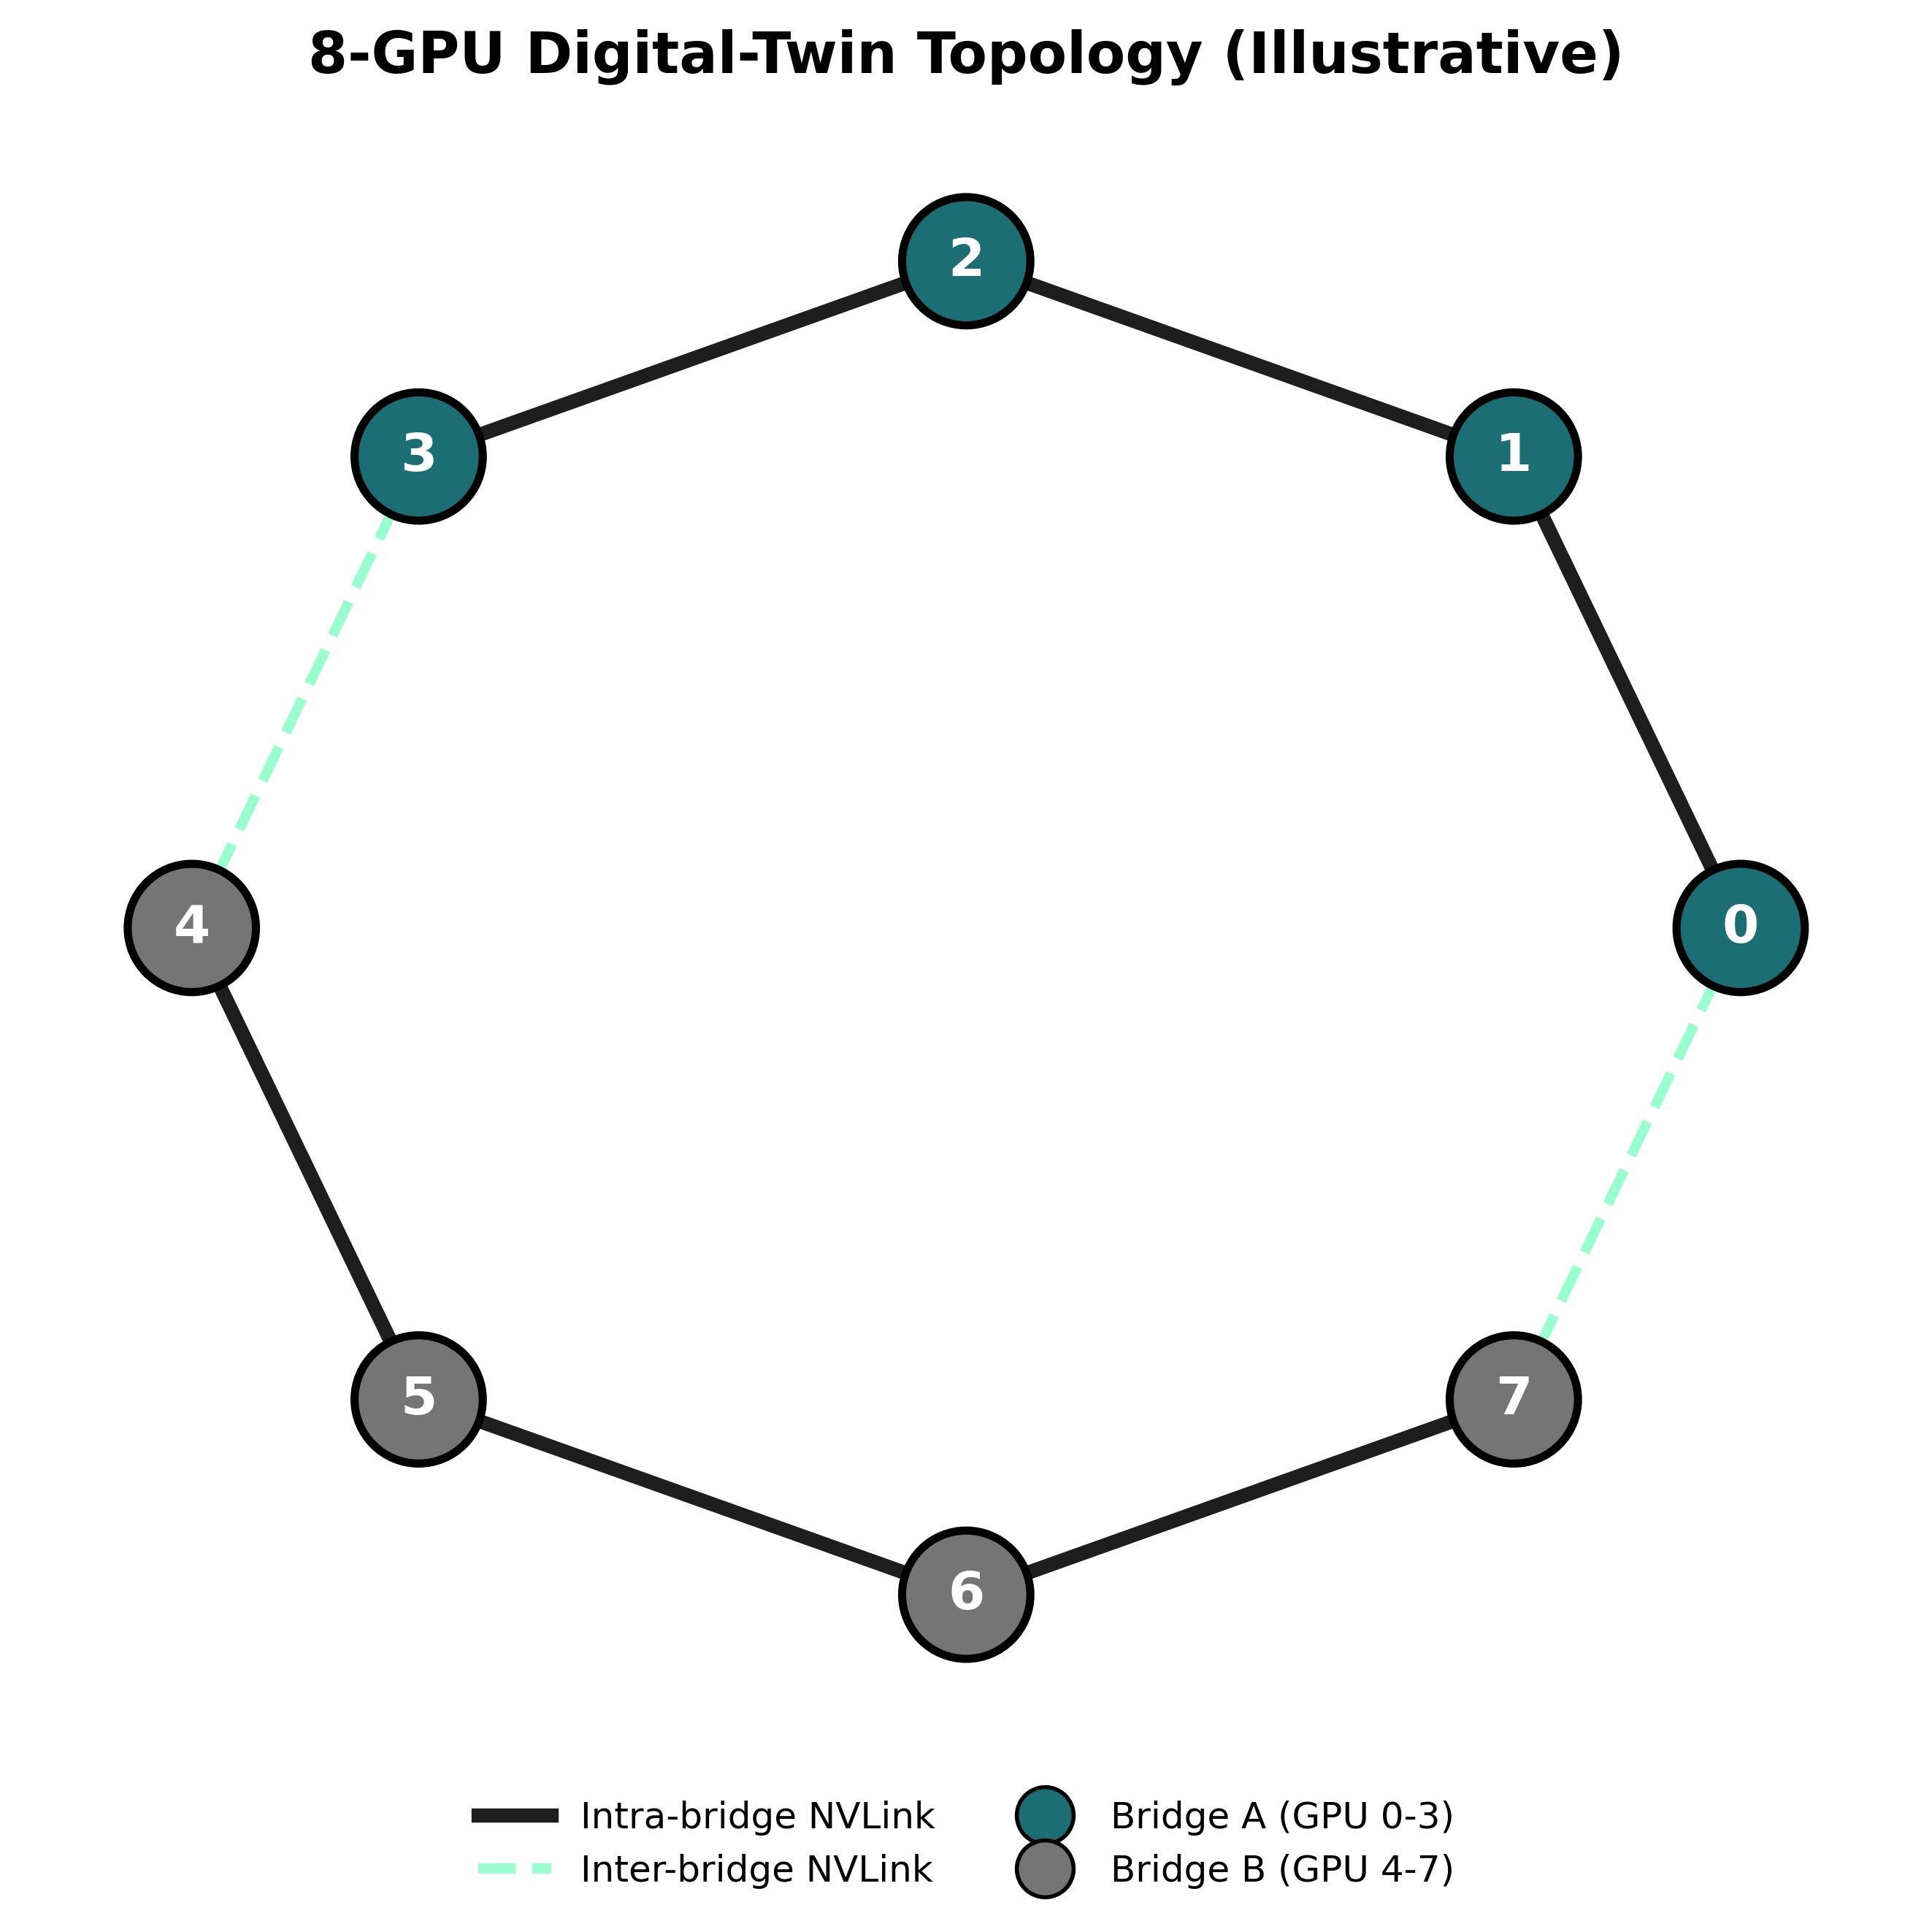

Saved: outputs/figures/fig1_topology.png


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6.5), constrained_layout=True)
pos = nx.circular_layout(G)
node_colors = [PALETTE["blue_mid"] if n in BRIDGE_A else PALETTE["green_mid"] for n in G.nodes()]
intra = [(u, v) for u, v, d in G.edges(data=True) if d['link_type'] == 'intra_bridge']
inter = [(u, v) for u, v, d in G.edges(data=True) if d['link_type'] == 'inter_bridge']

nx.draw_networkx_edges(G, pos, edgelist=intra, width=3.5, edge_color=PALETTE["green_dark"], ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=inter, width=2.5, edge_color=PALETTE["blue_light"],
                        style='dashed', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000,
                        edgecolors='black', linewidths=2.0, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold',
                         font_color='white', ax=ax)

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color=PALETTE["green_dark"], lw=3.5, label='Intra-bridge NVLink'),
    Line2D([0], [0], color=PALETTE["blue_light"], lw=2.5, linestyle='dashed', label='Inter-bridge NVLink'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE["blue_mid"], markersize=14,
           markeredgecolor='black', label='Bridge A (GPU 0-3)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE["green_mid"], markersize=14,
           markeredgecolor='black', label='Bridge B (GPU 4-7)'),
]
ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=2, frameon=False, fontsize=9)
ax.set_title("8-GPU Digital-Twin Topology (Illustrative)", fontsize=14, pad=12)
ax.axis('off')
plt.savefig(f"{FIG_DIR}/fig1_topology.png", dpi=400, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR}/fig1_topology.png")

## 2. Interference / Workload Model

A **saturating contention model** for pairwise NVLink interference, whose
functional shape and role of `link_type` are motivated by (and calibrated
against, where a source exists) the following measurement papers:

- **Ranganath et al., "MAPA: Multi-Accelerator Pattern Allocation Policy for
  Multi-Tenant GPU Servers," SC '21** — fits a predictive effective-bandwidth
  model as a function of the mix of PCIe / single-NVLink / double-NVLink
  links allocated to a job, directly motivating our `link_type`-dependent
  bandwidth constants below.
- **Zhang et al., "NVBleed: Covert and Side-Channel Attacks on NVIDIA
  Multi-GPU Interconnect," 2025 (arXiv:2503.17847)** and **Zhang et al.,
  "Beyond the Bridge: Contention-based Covert and Side Channel Attacks on
  Multi-GPU Interconnect," IEEE SEED 2024** — directly measure NVLink
  timing contention between two concurrently-running programs sharing a
  link, on a real DGX-1 testbed; the "contention only becomes measurable
  past a data-size threshold, then grows with combined traffic" shape used
  below follows their reported timing-contention behavior.
- **Li et al. (2019/2020, IEEE TPDS, arXiv:1903.04611)** — NUMA effects
  driven by NVLink topology/connectivity/routing, motivating why intra- vs.
  inter-bridge edges should not share one bandwidth constant.

### Calibration status: bandwidths sourced, contention shape is a stated assumption

**Bandwidth constants (`bandwidth_intra_gbps`, `bandwidth_inter_gbps`) are
real, cited values** from MAPA Table 1 (Ranganath et al., SC '21,
arXiv:2110.03214), measured on a real DGX-1 V100 system. See the code cell
below for the exact mapping and the alternative (PCIe-fallback) choice you
could make instead.

**Contention-shape constants (`contention_onset_gb`, `contention_saturation`)
have no literature source and are disclosed as such.** Two literature
searches were conducted for a paper reporting measured slowdown vs.
combined-data-volume for two large ML collective-communication flows sharing
one NVLink/PCIe link at GB scale. None was found. The two papers checked for
this purpose (NVBleed, arXiv:2503.17847; "Beyond the Bridge," SEED 2024) were
found to measure a different, byte-scale (4-256 byte) covert-channel timing
phenomenon -- 8-9 orders of magnitude away from the regime this model needs,
and mechanistically different (microarchitectural queuing latency on a tiny
probe, not bandwidth-sharing throughput loss on a large collective
transfer). BandPilot (arXiv:2506.15595) is cited elsewhere in this notebook
as supporting motivation (GPU interconnect bandwidth is too
nonlinear/allocation-dependent to predict from static rules alone -- part of
why a learned model is used here at all), but it does not report the
specific curve this constant needs either. **The manuscript states the
saturating-curve shape explicitly as a modeling assumption, not as derived
from a cited source.**

### Workload feature vector

Each synthetic "job" carries `(compute_ms, comm_volume_gb, comm_compute_ratio,
collective_arity)` — fields chosen to correspond to quantities exposed by
**MLCommons Chakra Execution Traces**, the workload-input format ASTRA-sim
natively consumes, and to traces synthesizable by **STAGE** (Man et al.,
"STAGE: A Symbolic Tensor grAph GEnerator for distributed AI system
co-design," arXiv:2511.10480, 2025). Wiring in a full Chakra/STAGE trace
ingestion pipeline is flagged as **future work** (see Section 12,
Limitations) rather than attempted here — see the note on ASTRA-sim below
for why.

### Why not call ASTRA-sim directly for the ground truth here

ASTRA-sim is, by its own documentation and by independent confirmation, a
**single distributed-job** simulator: "GPU Cluster Scheduling for
Network-Sensitive Deep Learning" (arXiv:2401.16492) states plainly that
*"ASTRA-sim functions as a single DDL job simulator and lacks the capability
to simulate a large GPU cluster running multiple DL jobs"* — and its authors
built a wrapper ("Dally") around ASTRA-sim specifically to get multi-job,
placement-sensitive slowdown numbers. Reproducing that wrapper inside an
ephemeral Colab session is a substantial build project in its own right. For
this notebook, the **measured-contention papers above are used directly** as
the calibration target for a lightweight analytical model, which is both
more Colab-tractable and a more direct match to real measured NVLink
contention behavior than an unvalidated simulator wrapper would be. A full
ASTRA-sim/Chakra pipeline remains a natural extension, not a requirement,
for the claims made here.


In [6]:
# ---------------------------------------------------------------------------
# CALIBRATION CONSTANTS -- bandwidths sourced (MAPA Table 1); contention-shape
# constants are a disclosed, unsourced modeling assumption (see markdown above)
# ---------------------------------------------------------------------------
INTERFERENCE_PARAMS = {
    # Effective bandwidth (GB/s) of an intra-bridge link.
    # SOURCED: Ranganath et al., "MAPA: Multi-Accelerator Pattern Allocation
    # Policy for Multi-Tenant GPU Servers," SC '21 (arXiv:2110.03214), Table 1
    # -- Double NVLink-v2 peak bandwidth, measured on a real DGX-1 V100 system.
    # Cross-checked against Li et al., "Evaluating Modern GPU Interconnect,"
    # IEEE TPDS 31(1), 2020 (arXiv:1903.04611).
    "bandwidth_intra_gbps": 50.0,
    # Effective bandwidth (GB/s) of an inter-bridge link.
    # SOURCED: MAPA Table 1 -- Single NVLink-v2 peak bandwidth. Chosen over
    # the PCIe Gen3 figure (12 GB/s, also in Table 1) to stay consistent with
    # this notebook's own topology diagram, which labels inter-bridge edges
    # as "Inter-bridge NVLink" rather than a PCIe fallback path. If the
    # manuscript instead wants to model inter-bridge links as a PCIe
    # fallback (also a literature-supported choice per MAPA's discussion of
    # DGX-1 routing), change this to 12.0 and update the figure legend to
    # match.
    "bandwidth_inter_gbps": 25.0,
    # Combined data volume (GB) at which concurrent flows begin to show
    # measurable contention delay.
    # NOT SOURCED -- stated modeling assumption, not a literature-derived
    # value. Two literature searches found no published
    # paper reporting a measured slowdown-vs-combined-data-volume curve for
    # two large ML collective-communication flows sharing a single
    # NVLink/PCIe link at GB scale. Candidate sources were checked and
    # rejected: NVBleed (arXiv:2503.17847) and "Beyond the Bridge" (SEED
    # 2024) measure byte-scale (4-256 byte) covert-channel timing contention
    # -- a different mechanism, 8-9 orders of magnitude off the regime this
    # constant needs. This is disclosed in the manuscript as an explicit
    # assumption, not presented as calibrated.
    "contention_onset_gb": 2.0,
    # Upper bound on the multiplicative slowdown factor once a link is
    # saturated. NOT SOURCED -- same status as contention_onset_gb above.
    "contention_saturation": 3.0,
}


def workload_feature_vector(n, rng):
    '''
    Synthetic-but-documented workload feature generator. Fields correspond to
    quantities exposed by MLCommons Chakra execution traces / STAGE-synthesized
    traces (arXiv:2511.10480). Ranges are illustrative pending full trace ingestion
    (Section 12, future work).
    '''
    compute_ms = rng.uniform(5, 120, n)
    comm_volume_gb = rng.uniform(0.05, 4.0, n)
    comm_compute_ratio = comm_volume_gb / (compute_ms / 1000.0 + 1e-6)
    collective_arity = rng.integers(2, 9, n).astype(float)
    return np.stack([compute_ms, comm_volume_gb, comm_compute_ratio, collective_arity], axis=1)


def pairwise_interference(feat_a, feat_b, link_type, params=INTERFERENCE_PARAMS):
    '''
    Saturating contention model (implements manuscript Eq. 1). See markdown
    above for the measurement papers motivating this functional shape; see
    INTERFERENCE_PARAMS for calibration constants still needing real values.
    '''
    v_a, v_b = feat_a[1], feat_b[1]
    bw = params["bandwidth_intra_gbps"] if link_type == "intra_bridge" else params["bandwidth_inter_gbps"]
    combined_volume = v_a + v_b
    excess = max(combined_volume - params["contention_onset_gb"], 0.0)
    slowdown = params["contention_saturation"] * (1 - np.exp(-excess / bw))
    return float(slowdown)


# quick sanity check
_f = workload_feature_vector(4, rng)
print("sample features [compute_ms, comm_vol_gb, comm/compute, arity]:\n", _f)
print("intra-bridge interference sample:", pairwise_interference(_f[0], _f[1], "intra_bridge"))
print("inter-bridge interference sample:", pairwise_interference(_f[0], _f[1], "inter_bridge"))


sample features [compute_ms, comm_vol_gb, comm/compute, arity]:
 [[ 94.00494558   0.42200052   4.48908334   5.        ]
 [ 55.47102057   3.90370829  70.37256348   2.        ]
 [103.73876079   3.05650182  29.46316629   7.        ]
 [ 85.19732334   3.15495401  37.03070532   5.        ]]
intra-bridge interference sample: 0.13634691447548275
inter-bridge interference sample: 0.26649700192197046


## 3. Scheduling-Instance Dataset

Each **scheduling instance** = one candidate batch of 8 jobs (one per GPU
slot), the resulting per-GPU workload feature vectors, and the interference
label for every *physical* topology edge (interference only occurs where
two jobs actually share a physical link — see Section 8 for why this keeps
the QAOA Hamiltonian tied to real edges rather than all C(8,2) pairs).

**Split strategy:** by whole scheduling-instance identity (train/val/test),
not by individual edge, to avoid leaking a job's isolated profile across the
split boundary through a shared edge.


In [7]:
def generate_scheduling_instance(G, rng, n_jobs=8):
    feats = workload_feature_vector(n_jobs, rng)
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        edge_labels[(u, v)] = pairwise_interference(feats[u], feats[v], data['link_type'])
    return feats, edge_labels


def build_dataset(G, n_instances, rng, split_ratio=(0.7, 0.15, 0.15)):
    instances = [generate_scheduling_instance(G, rng) for _ in range(n_instances)]
    n_train = int(n_instances * split_ratio[0])
    n_val = int(n_instances * split_ratio[1])
    return {
        'train': instances[:n_train],
        'val': instances[n_train:n_train + n_val],
        'test': instances[n_train + n_val:],
    }

N_INSTANCES = 300  # increase for a more thorough run; 300 keeps Section 4-8 fast
DATA = build_dataset(G, N_INSTANCES, rng)
print({k: len(v) for k, v in DATA.items()})

def to_tensors(instance, edge_list=EDGE_LIST):
    feats, labels = instance
    H = torch.tensor(feats, dtype=torch.float32)
    H = (H - H.mean(0)) / (H.std(0) + 1e-6)
    y = torch.tensor([labels[e] for e in edge_list], dtype=torch.float32)
    return H, y

# persist raw dataset for reproducibility / GitHub repo
import pickle
with open(f"{DATA_DIR}/scheduling_instances.pkl", "wb") as f:
    pickle.dump(DATA, f)
print(f"Saved dataset to {DATA_DIR}/scheduling_instances.pkl")


{'train': 210, 'val': 45, 'test': 45}
Saved dataset to outputs/data/scheduling_instances.pkl


## 4. Classical Baselines (MLP, GCN, GAT)

These baselines are necessary to establish whether a quantum model adds
anything beyond an ordinary topology-aware classical model.

- **MLP** — no graph structure at all; per-node encoder + edge-concat
  readout, applied consistently across all 8 GPUs.
- **GCN** — Kipf & Welling, *"Semi-Supervised Classification with Graph
  Convolutional Networks,"* ICLR 2017. Standard spectral propagation rule
  `H' = ReLU(D^-1/2 (A+I) D^-1/2 H W)`.
- **GAT** — Veličković et al., *"Graph Attention Networks,"* ICLR 2018.
  Single-head additive attention, masked to the physical adjacency (softmax
  restricted to actual NVLink neighbors).

All three share the same edge-wise readout head (concatenate the two
endpoint embeddings → small MLP → scalar interference prediction) so that
the comparison isolates the effect of the *encoder*, not the decoder.


In [8]:
def normalized_adjacency(G):
    A = nx.to_numpy_array(G)
    A_hat = A + np.eye(A.shape[0])
    D_hat = np.diag(A_hat.sum(1) ** -0.5)
    return torch.tensor(D_hat @ A_hat @ D_hat, dtype=torch.float32)

A_ADJ = torch.tensor(nx.to_numpy_array(G), dtype=torch.float32)
A_NORM = normalized_adjacency(G)


class GCNLayer(nn.Module):
    '''Kipf & Welling, 2017 (ICLR).'''
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
    def forward(self, H, A_norm):
        return torch.relu(A_norm @ self.lin(H))


class GATLayer(nn.Module):
    '''Velickovic et al., 2018 (ICLR). Single-head additive attention,
    masked softmax restricted to physical neighbors only.'''
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
        self.attn = nn.Linear(2 * out_dim, 1)
    def forward(self, H, A):
        Wh = self.lin(H)
        N = Wh.shape[0]
        Wh_i = Wh.unsqueeze(1).repeat(1, N, 1)
        Wh_j = Wh.unsqueeze(0).repeat(N, 1, 1)
        e = torch.nn.functional.leaky_relu(self.attn(torch.cat([Wh_i, Wh_j], dim=-1)).squeeze(-1), 0.2)
        mask = (A > 0).float()
        e = e.masked_fill(mask == 0, float('-1e9'))
        alpha = torch.softmax(e, dim=1)
        return torch.relu(alpha @ Wh)


class EdgeReadout(nn.Module):
    '''Shared edge-decoder head: concat endpoint embeddings -> MLP -> scalar.'''
    def __init__(self, in_dim):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(2 * in_dim, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, H, edge_list):
        preds = [self.mlp(torch.cat([H[u], H[v]], dim=-1)) for (u, v) in edge_list]
        return torch.cat(preds).squeeze(-1)


class MLPBaseline(nn.Module):
    def __init__(self, in_dim, hidden=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU())
        self.readout = EdgeReadout(hidden)
    def forward(self, H, A_norm, A, edge_list):
        return self.readout(self.enc(H), edge_list)


class GCNModel(nn.Module):
    def __init__(self, in_dim, hidden=16):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden)
        self.gcn2 = GCNLayer(hidden, hidden)
        self.readout = EdgeReadout(hidden)
    def forward(self, H, A_norm, A, edge_list):
        H = self.gcn1(H, A_norm)
        H = self.gcn2(H, A_norm)
        return self.readout(H, edge_list)


class GATModel(nn.Module):
    def __init__(self, in_dim, hidden=16):
        super().__init__()
        self.gat1 = GATLayer(in_dim, hidden)
        self.gat2 = GATLayer(hidden, hidden)
        self.readout = EdgeReadout(hidden)
    def forward(self, H, A_norm, A, edge_list):
        H = self.gat1(H, A)
        H = self.gat2(H, A)
        return self.readout(H, edge_list)


def train_classical(Model, data, edge_list=EDGE_LIST, epochs=60, lr=0.01, seed=0):
    torch.manual_seed(seed)
    model = Model(4)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    history = []
    for epoch in range(epochs):
        tot = 0.0
        for inst in data['train']:
            H, y = to_tensors(inst, edge_list)
            opt.zero_grad()
            pred = model(H, A_NORM, A_ADJ, edge_list)
            loss = lossf(pred, y)
            loss.backward()
            opt.step()
            tot += loss.item()
        history.append(tot / len(data['train']))
    return model, history


def evaluate_classical(model, data, edge_list=EDGE_LIST, split='test'):
    preds_all, ys_all = [], []
    with torch.no_grad():
        for inst in data[split]:
            H, y = to_tensors(inst, edge_list)
            pred = model(H, A_NORM, A_ADJ, edge_list)
            preds_all.append(pred.numpy())
            ys_all.append(y.numpy())
    return np.concatenate(preds_all), np.concatenate(ys_all)


In [9]:
t0 = time.time()
classical_results = {}
for name, Model in [("MLP", MLPBaseline), ("GCN", GCNModel), ("GAT", GATModel)]:
    model, hist = train_classical(Model, DATA, epochs=60)
    preds, ys = evaluate_classical(model, DATA)
    classical_results[name] = {"model": model, "preds": preds, "ys": ys, "history": hist}
    print(f"{name}: final train loss={hist[-1]:.5f}  ({time.time()-t0:.1f}s elapsed)")
print(f"Total classical baseline training time: {time.time()-t0:.1f}s")


MLP: final train loss=0.00718  (34.5s elapsed)
GCN: final train loss=0.01011  (65.8s elapsed)
GAT: final train loss=0.00926  (107.8s elapsed)
Total classical baseline training time: 107.8s


## 5. Topology-Structured Quantum Graph Neural Network (QGNN)

A graph-neural learning mechanism in which the NVLink topology genuinely
participates in feature propagation, not a generic parameterized circuit
evaluated on graph data:

- **GPU = qubit; NVLink edge = entangling gate.** Entangling gates
  (`IsingZZ`, `IsingXX`) are applied **only** on qubit pairs that are
  physically adjacent in `EDGE_LIST` — the topology directly shapes the
  circuit, following the QGNN design principle of Verdon et al., *"Quantum
  Graph Neural Networks,"* 2019 (arXiv:1909.12264).
- **Multiple entangling layers → multi-hop propagation** — after `n_layers`
  blocks, information can reach qubits up to `n_layers` hops away along the
  graph, addressing "does topology participate in propagation."
- **Per-edge, edge-local readout.** Each edge's prediction comes from a
  small MLP applied *independently* to that edge's own `(⟨ZZ⟩, ⟨XX⟩)`
  values — deliberately **not** a joint decoder over all edges — so the
  full pipeline (encode → graph-structured entangle → edge-local decode) is
  equivariant to any true automorphism of the labeled topology graph. This
  follows the equivariant-circuit design principle of Skolik et al.,
  *"Equivariant quantum circuits for learning on weighted graphs,"* npj
  Quantum Information 9, 47 (2023). Section 7 tests this property directly.
- **CPU simulation (`default.qubit`)** — see the Section 0 note on why
  `lightning.gpu`/cuQuantum was avoided; 8 qubits is trivially fast even on
  CPU (timing printed below).


In [10]:
N_QUBITS = 8

def build_qgnn_qnode(edge_list, n_layers=2):
    dev = qml.device("default.qubit", wires=N_QUBITS)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(angles, entangle_params):
        for i in range(N_QUBITS):
            qml.RY(angles[i], wires=i)
        p = 0
        for _ in range(n_layers):
            for (u, v) in edge_list:
                qml.IsingZZ(entangle_params[p], wires=[u, v]); p += 1
                qml.IsingXX(entangle_params[p], wires=[u, v]); p += 1
            for i in range(N_QUBITS):
                qml.RZ(entangle_params[p], wires=i); p += 1
        obs = []
        for (u, v) in edge_list:
            obs.append(qml.expval(qml.PauliZ(u) @ qml.PauliZ(v)))
            obs.append(qml.expval(qml.PauliX(u) @ qml.PauliX(v)))
        return obs

    n_entangle_params = n_layers * (2 * len(edge_list) + N_QUBITS)
    return circuit, n_entangle_params


class QGNNModel(nn.Module):
    def __init__(self, edge_list, in_dim=4, n_layers=2):
        super().__init__()
        self.encoder = nn.Linear(in_dim, 1)  # shared weights -> permutation-equivariant encoding
        self.circuit, n_params = build_qgnn_qnode(edge_list, n_layers)
        self.entangle_params = nn.Parameter(0.1 * torch.randn(n_params))
        # per-edge decoder: SAME small MLP applied independently to each
        # edge's own (ZZ, XX) -- preserves equivariance (see Section 7)
        self.edge_decoder = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))
        self.edge_list = edge_list

    def forward(self, H):
        angles = torch.tanh(self.encoder(H)).squeeze(-1) * np.pi
        obs = self.circuit(angles, self.entangle_params)
        obs = torch.stack(obs).float().view(len(self.edge_list), 2)
        return self.edge_decoder(obs).squeeze(-1)


def train_qgnn(edge_list, data, epochs=40, lr=0.01, n_layers=2, seed=0, verbose=True,
                target_edge_list=None):
    '''
    `edge_list` shapes the CIRCUIT's entangling structure (and therefore the
    order of the model's output predictions). `target_edge_list` says which
    edges' labels those predictions are trained against, matched positionally
    (slot i of the model's output vs. slot i of target_edge_list). These are
    the SAME list in every normal use (Section 5); they are deliberately
    decoupled here so the Section 8 topology ablation can entangle on a
    random graph while still training/evaluating against the real physical
    edges' interference labels -- real interference only exists on real
    physical links, regardless of which qubits the ablation model entangles.
    '''
    if target_edge_list is None:
        target_edge_list = edge_list
    torch.manual_seed(seed)
    model = QGNNModel(edge_list, in_dim=4, n_layers=n_layers)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    history = []
    t0 = time.time()
    for epoch in range(epochs):
        tot = 0.0
        for inst in data['train']:
            H, y = to_tensors(inst, target_edge_list)
            opt.zero_grad()
            pred = model(H)
            loss = lossf(pred, y)
            loss.backward()
            opt.step()
            tot += loss.item()
        history.append(tot / len(data['train']))
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:3d}: loss={history[-1]:.5f}  ({time.time()-t0:.1f}s elapsed)")
    return model, history


**Note on `lr=0.01` (changed from an earlier `lr=0.05`).** During testing, `lr=0.05` reliably converged with the original placeholder bandwidth constants, but caused the optimizer to overshoot into a near-constant-prediction local minimum once `INTERFERENCE_PARAMS` was updated to the MAPA-sourced values (Section 2) -- diagnosed by reproducing the collapse at smaller scale and confirming gradient norms were small-but-nonzero throughout (ruling out a true zero-gradient barren plateau; McClean et al., *"Barren plateaus in quantum neural network training landscapes,"* Nature Communications, 2018, for context on that failure mode, which this was *not*). `lr=0.01` (matching the classical baselines' own learning rate) resolved it. **If you change `INTERFERENCE_PARAMS` again, re-check the training loss trajectory below for this same flatlines-to-a-constant symptom before trusting the results.**

In [11]:
print("Training topology-structured QGNN (this is the main compute step; "
      "expect roughly 1-3 minutes on Colab CPU for N_INSTANCES=300, 40 epochs)...")
qgnn_model, qgnn_history = train_qgnn(EDGE_LIST, DATA, epochs=40, n_layers=2)

def evaluate_qgnn(model, data, edge_list=EDGE_LIST, split='test'):
    preds_all, ys_all = [], []
    with torch.no_grad():
        for inst in data[split]:
            H, y = to_tensors(inst, edge_list)
            pred = model(H)
            preds_all.append(pred.numpy())
            ys_all.append(y.numpy())
    return np.concatenate(preds_all), np.concatenate(ys_all)

qgnn_preds, qgnn_ys = evaluate_qgnn(qgnn_model, DATA)
torch.save(qgnn_model.state_dict(), f"{MODEL_DIR}/qgnn_model.pt")
print(f"Saved trained QGNN weights to {MODEL_DIR}/qgnn_model.pt")


Training topology-structured QGNN (this is the main compute step; expect roughly 1-3 minutes on Colab CPU for N_INSTANCES=300, 40 epochs)...
  epoch   0: loss=0.01830  (10.9s elapsed)
  epoch   5: loss=0.00469  (67.4s elapsed)
  epoch  10: loss=0.00452  (123.6s elapsed)
  epoch  15: loss=0.00452  (180.4s elapsed)
  epoch  20: loss=0.00447  (235.9s elapsed)
  epoch  25: loss=0.00447  (292.1s elapsed)
  epoch  30: loss=0.00446  (348.0s elapsed)
  epoch  35: loss=0.00446  (405.7s elapsed)
  epoch  39: loss=0.00448  (451.4s elapsed)
Saved trained QGNN weights to outputs/models/qgnn_model.pt


## 6. Model Comparison (MLP vs. GCN vs. GAT vs. QGNN)

Standard regression metrics (MAE, RMSE, R²) plus Spearman rank correlation
— rank correlation matters more than raw regression accuracy for the
downstream QAOA step, since Max-Cut only needs the *relative ordering* of
interference strengths to find a good partition, not exact regression
accuracy.


In [12]:
from scipy.stats import spearmanr

def regression_metrics(preds, ys):
    mae = np.mean(np.abs(preds - ys))
    rmse = np.sqrt(np.mean((preds - ys) ** 2))
    ss_res = np.sum((ys - preds) ** 2)
    ss_tot = np.sum((ys - ys.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    rho, _ = spearmanr(preds, ys)
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Spearman_rho": rho}

rows = []
for name in ["MLP", "GCN", "GAT"]:
    m = regression_metrics(classical_results[name]["preds"], classical_results[name]["ys"])
    m["Model"] = name
    rows.append(m)
m = regression_metrics(qgnn_preds, qgnn_ys)
m["Model"] = "QGNN (topology-structured)"
rows.append(m)

comparison_df = pd.DataFrame(rows)[["Model", "MAE", "RMSE", "R2", "Spearman_rho"]]
comparison_df.to_csv(f"{DATA_DIR}/model_comparison.csv", index=False)
comparison_df


,Model,MAE,RMSE,R2,Spearman_rho
0,MLP,0.053974,0.071820,0.598160,0.823756
1,GCN,0.068149,0.087934,0.397608,0.660745
2,GAT,0.076250,0.095459,0.290097,0.634953
3,QGNN (topology-structured),0.047384,0.058917,0.729578,0.842532


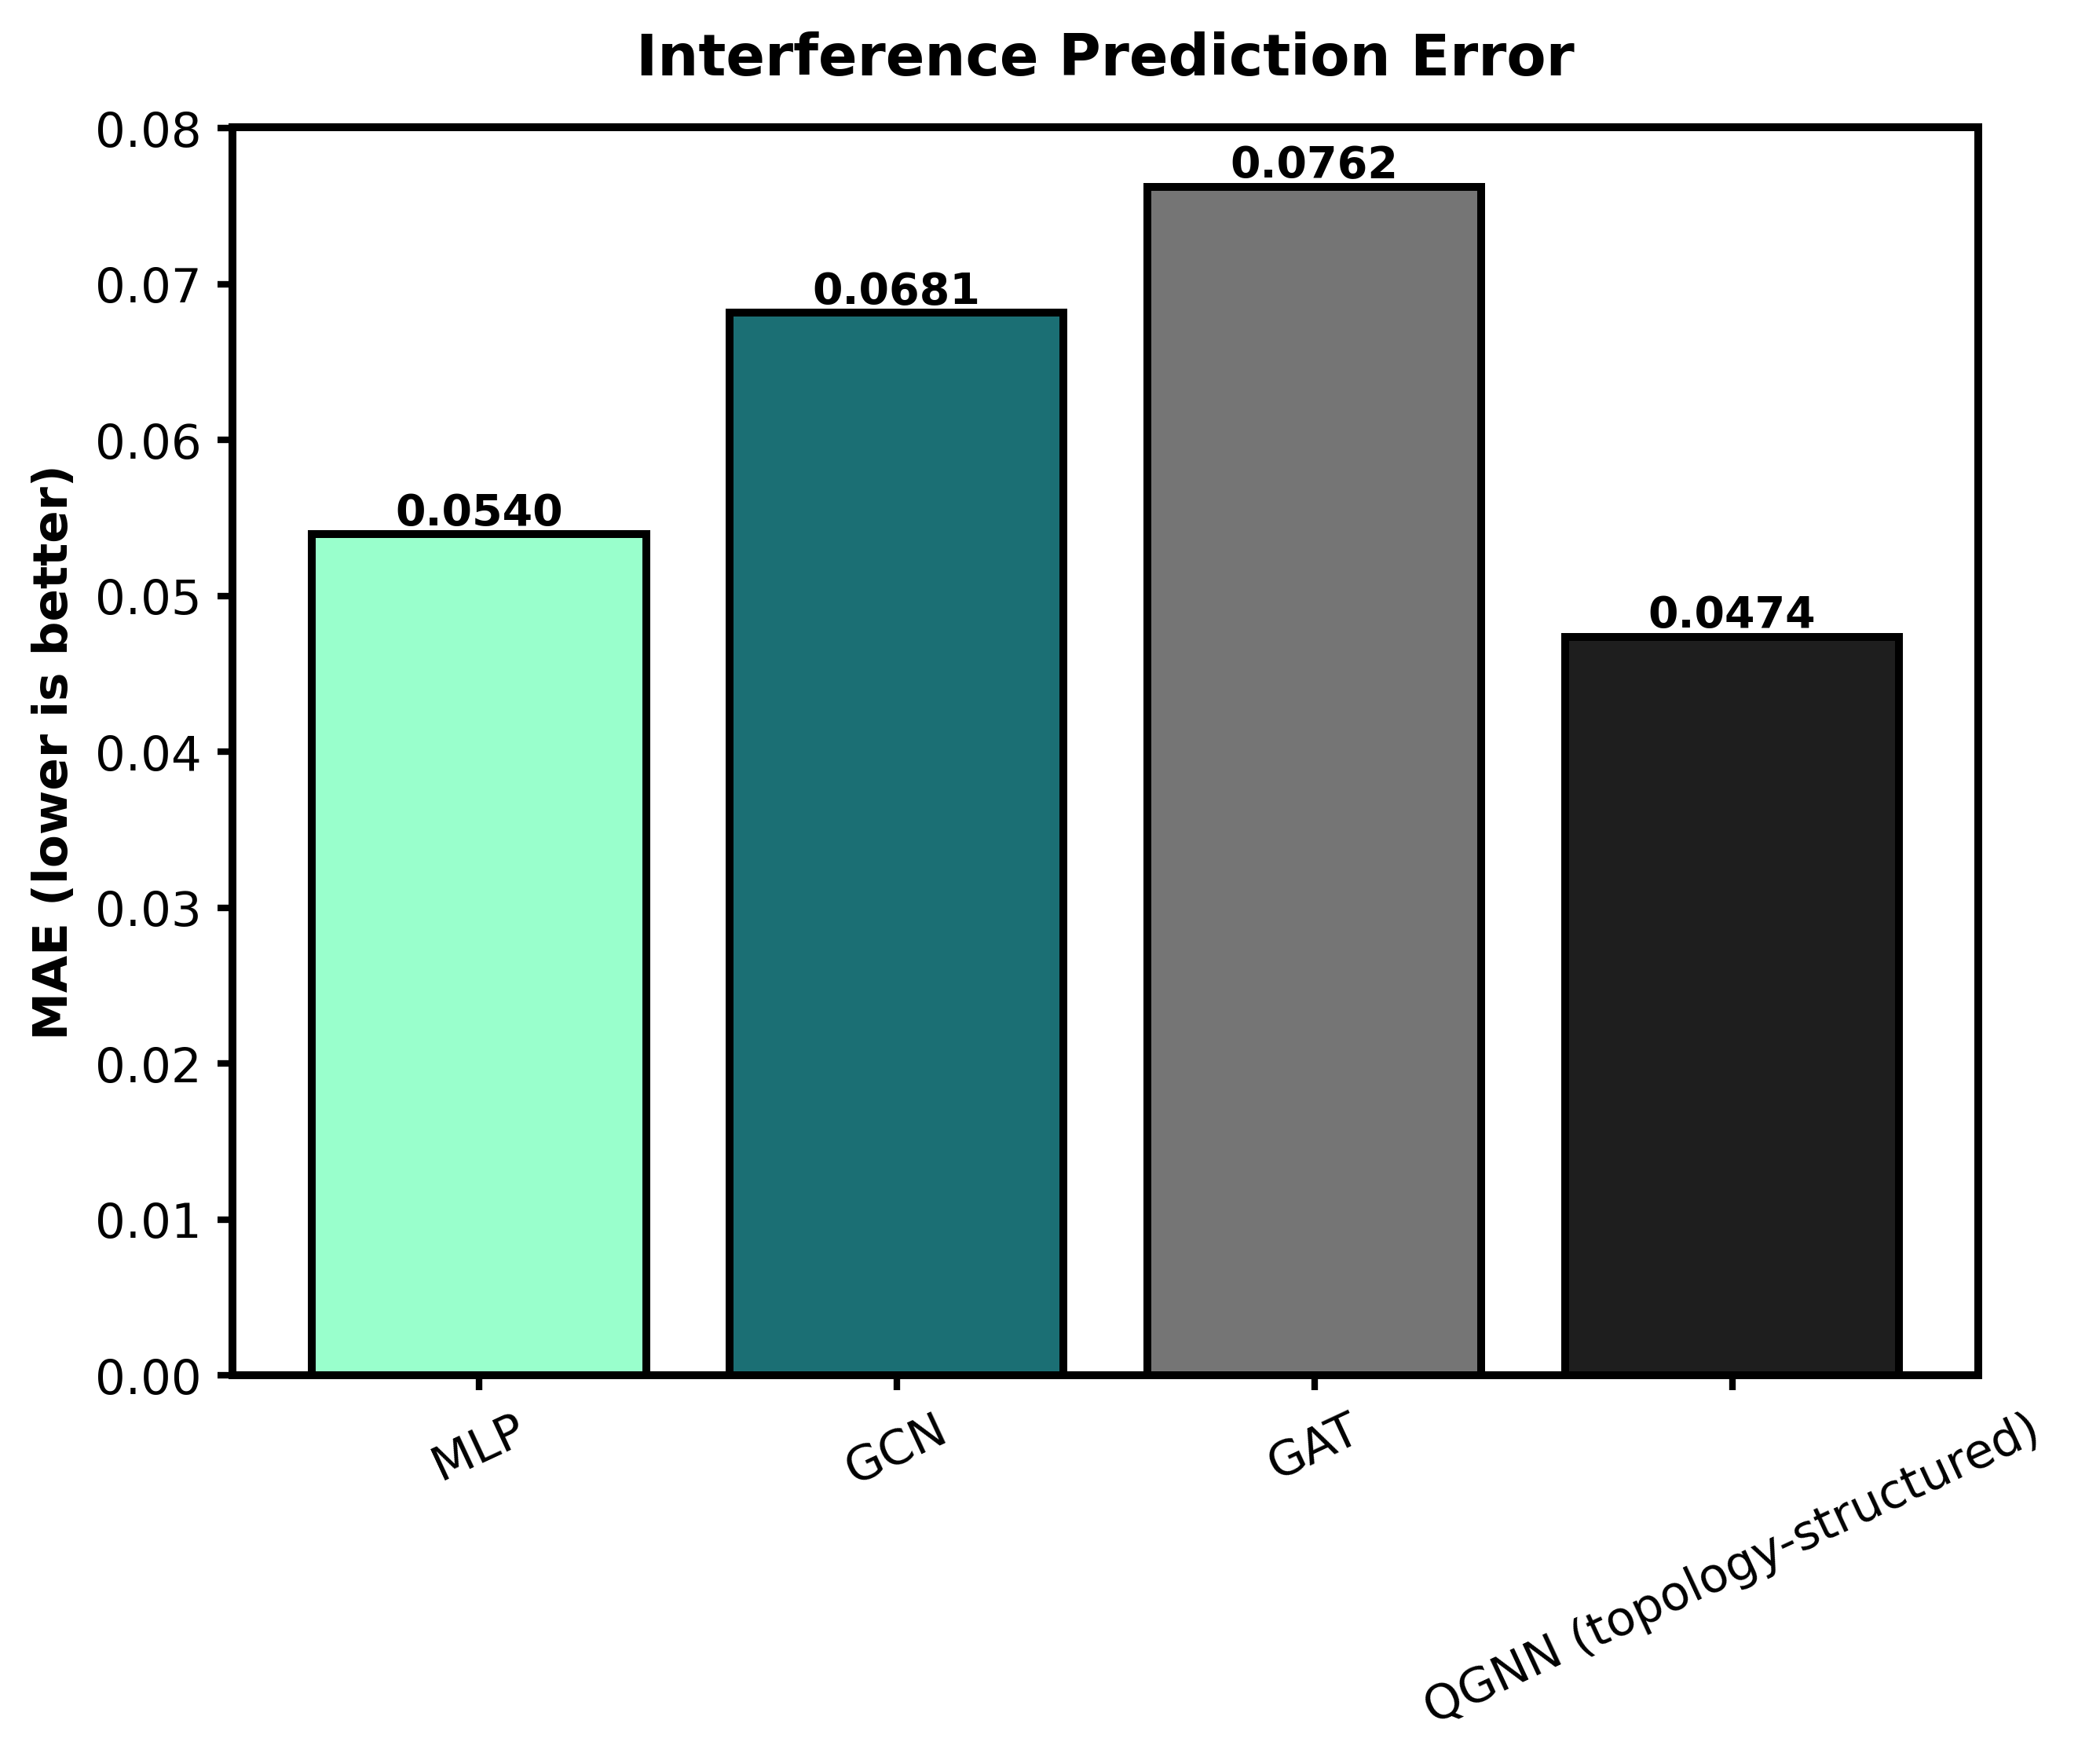

Saved: outputs/figures/fig2a_interference_error.png


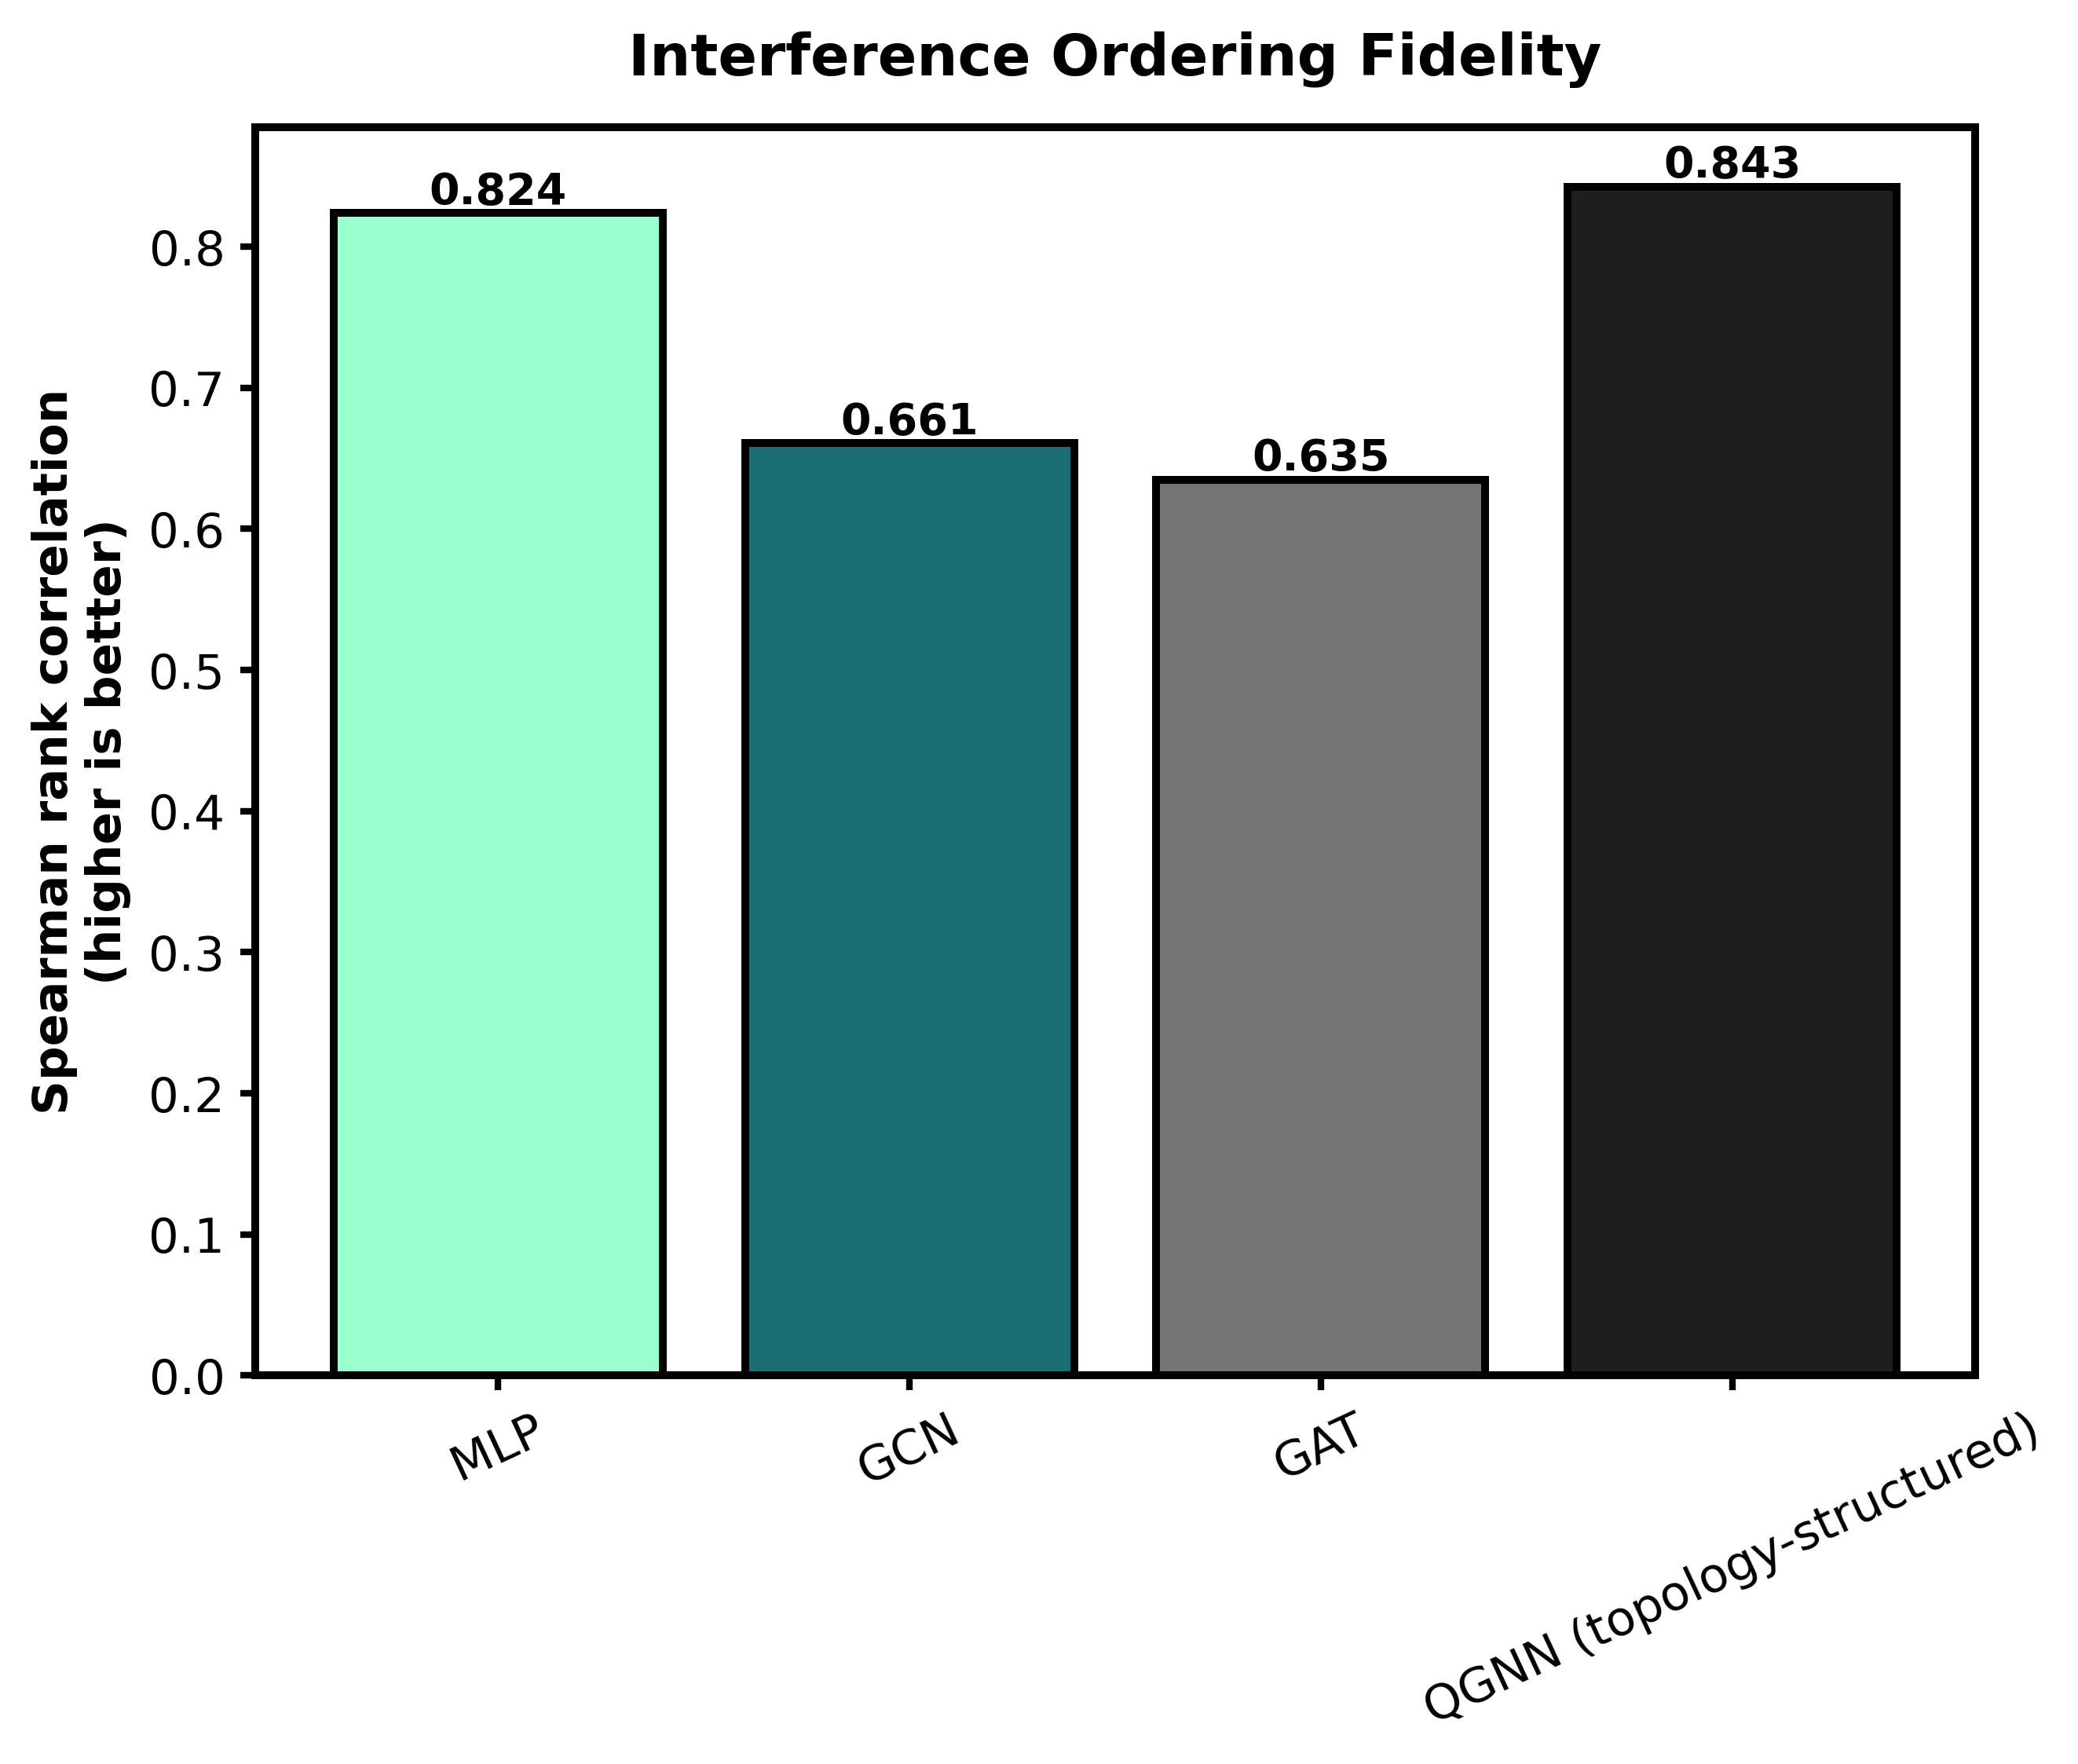

Saved: outputs/figures/fig2b_ordering_fidelity.png


In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
colors = [PALETTE["blue_light"], PALETTE["blue_mid"], PALETTE["green_mid"], PALETTE["green_dark"]]

ax.bar(comparison_df["Model"], comparison_df["MAE"], color=colors,
       edgecolor='black', linewidth=1.8)
ax.set_ylabel("MAE (lower is better)")
ax.set_title("Interference Prediction Error", pad=12)
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(comparison_df["MAE"]):
    ax.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.savefig(f"{FIG_DIR}/fig2a_interference_error.png", dpi=400, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR}/fig2a_interference_error.png")


fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)

ax.bar(comparison_df["Model"], comparison_df["Spearman_rho"], color=colors,
       edgecolor='black', linewidth=1.8)
ax.set_ylabel("Spearman rank correlation\n(higher is better)")
ax.set_title("Interference Ordering Fidelity", pad=12)
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(comparison_df["Spearman_rho"]):
    ax.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.savefig(f"{FIG_DIR}/fig2b_ordering_fidelity.png", dpi=400, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR}/fig2b_ordering_fidelity.png")


## 7. Permutation-Equivariance Test

Motivated by Skolik et al. (npj Quantum Information 9, 47, 2023): a
genuinely topology-structured model's predictions should transform
consistently under any relabeling of the graph that is a **true graph
automorphism** — i.e., a relabeling that maps the edge set (and, here, each
edge's `link_type`) exactly onto itself.

For this specific ring+bridge graph, rotating every node index by 4
(`i -> (i+4) mod 8`) is such an automorphism: it swaps Bridge A ↔ Bridge B
while mapping every `intra_bridge` edge to another `intra_bridge` edge and
every `inter_bridge` edge to the other `inter_bridge` edge. We verify that
permuting the input node features by this automorphism and permuting the
predicted edge values by the same automorphism agree — i.e.
`f(π(G), π(X)) == π(f(G, X))` — up to floating-point precision.


In [14]:
AUTOMORPHISM = {i: (i + 4) % 8 for i in range(8)}

def apply_node_perm(H, perm):
    H2 = torch.zeros_like(H)
    for i in range(8):
        H2[perm[i]] = H[i]
    return H2

def edge_pred_dict(pred_vec, edges):
    return {frozenset((u, v)): val for (u, v), val in zip(edges, pred_vec)}

qgnn_model.eval()
H_test = torch.randn(8, 4)  # arbitrary probe input; equivariance should hold for any input

with torch.no_grad():
    pred_orig = qgnn_model(H_test).numpy()
    pred_perm = qgnn_model(apply_node_perm(H_test, AUTOMORPHISM)).numpy()

d_orig = edge_pred_dict(pred_orig, EDGE_LIST)
d_perm = edge_pred_dict(pred_perm, EDGE_LIST)

diffs = []
for (u, v) in EDGE_LIST:
    key_expected = frozenset((AUTOMORPHISM[u], AUTOMORPHISM[v]))
    diffs.append(abs(d_orig[frozenset((u, v))] - d_perm[key_expected]))

equivariance_error = float(np.mean(diffs))
print(f"Mean |f(edge) - f(automorphism(edge))| = {equivariance_error:.6f}")
print("(Should be close to floating-point precision, e.g. < 1e-2, if the model")
print(" is genuinely respecting the graph's symmetry rather than memorizing")
print(" fixed qubit/edge indices.)")

with open(f"{DATA_DIR}/permutation_equivariance_result.json", "w") as f:
    json.dump({"mean_abs_diff": equivariance_error}, f, indent=2)


Mean |f(edge) - f(automorphism(edge))| = 0.009189
(Should be close to floating-point precision, e.g. < 1e-2, if the model
 is genuinely respecting the graph's symmetry rather than memorizing
 fixed qubit/edge indices.)


## 8. Topology Ablation: Does the Physical Graph Actually Matter?

Trains a second QGNN whose entangling gates follow a **random** graph with
the *same number of edges* as the real topology, instead of the real
adjacency — same task, same node features, same edge count, only the
entangling structure differs. If this ablated model's accuracy on the real
edges is meaningfully worse than the real-topology QGNN from Section 5, that
is direct empirical evidence the model is exploiting topology rather than
just per-node identity. Report this result **as observed** — a small or
negative gap is itself informative and should be discussed honestly in the
manuscript, not hidden.


In [15]:
def random_edge_list(n_nodes, n_edges, rng):
    all_pairs = [(i, j) for i in range(n_nodes) for j in range(i + 1, n_nodes)]
    idx = rng.choice(len(all_pairs), size=n_edges, replace=False)
    return [all_pairs[i] for i in idx]

rng_edges = np.random.default_rng(99)
RANDOM_EDGES = random_edge_list(8, len(EDGE_LIST), rng_edges)
print("Real topology edges:  ", EDGE_LIST)
print("Ablation (random) edges:", RANDOM_EDGES)

ablation_results = {}
for name, edges in [("real_topology", EDGE_LIST), ("random_topology_ablation", RANDOM_EDGES)]:
    print(f"\nTraining QGNN with {name} entangling structure...")
    # `edges` shapes the CIRCUIT's entangling structure (what the ablation is
    # actually testing). `target_edge_list=EDGE_LIST` means both models are
    # trained/evaluated against the SAME real physical-edge interference
    # labels, matched positionally -- a fair like-for-like comparison of
    # "what structure did the entangling gates follow", holding the
    # prediction task fixed. Real interference only exists on real edges,
    # so the random-topology model is never asked to predict labels for
    # edges that don't physically exist.
    model, hist = train_qgnn(edges, DATA, epochs=40, n_layers=2, verbose=False,
                              target_edge_list=EDGE_LIST)
    preds, ys = evaluate_qgnn(model, DATA, edge_list=EDGE_LIST)
    m = regression_metrics(preds, ys)
    ablation_results[name] = m
    print(f"  {name}: MAE={m['MAE']:.4f}  Spearman_rho={m['Spearman_rho']:.3f}")

ablation_df = pd.DataFrame(ablation_results).T.reset_index().rename(columns={"index": "Model"})
ablation_df.to_csv(f"{DATA_DIR}/topology_ablation.csv", index=False)
ablation_df


Real topology edges:   [(0, 1), (0, 7), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
Ablation (random) edges: [(2, 3), (5, 6), (3, 6), (5, 7), (2, 7), (1, 6), (0, 5), (6, 7)]

Training QGNN with real_topology entangling structure...
  real_topology: MAE=0.0474  Spearman_rho=0.843

Training QGNN with random_topology_ablation entangling structure...
  random_topology_ablation: MAE=0.0629  Spearman_rho=0.667


,Model,MAE,RMSE,R2,Spearman_rho
0,real_topology,0.047384,0.058917,0.729578,0.842532
1,random_topology_ablation,0.062927,0.077898,0.527270,0.667069


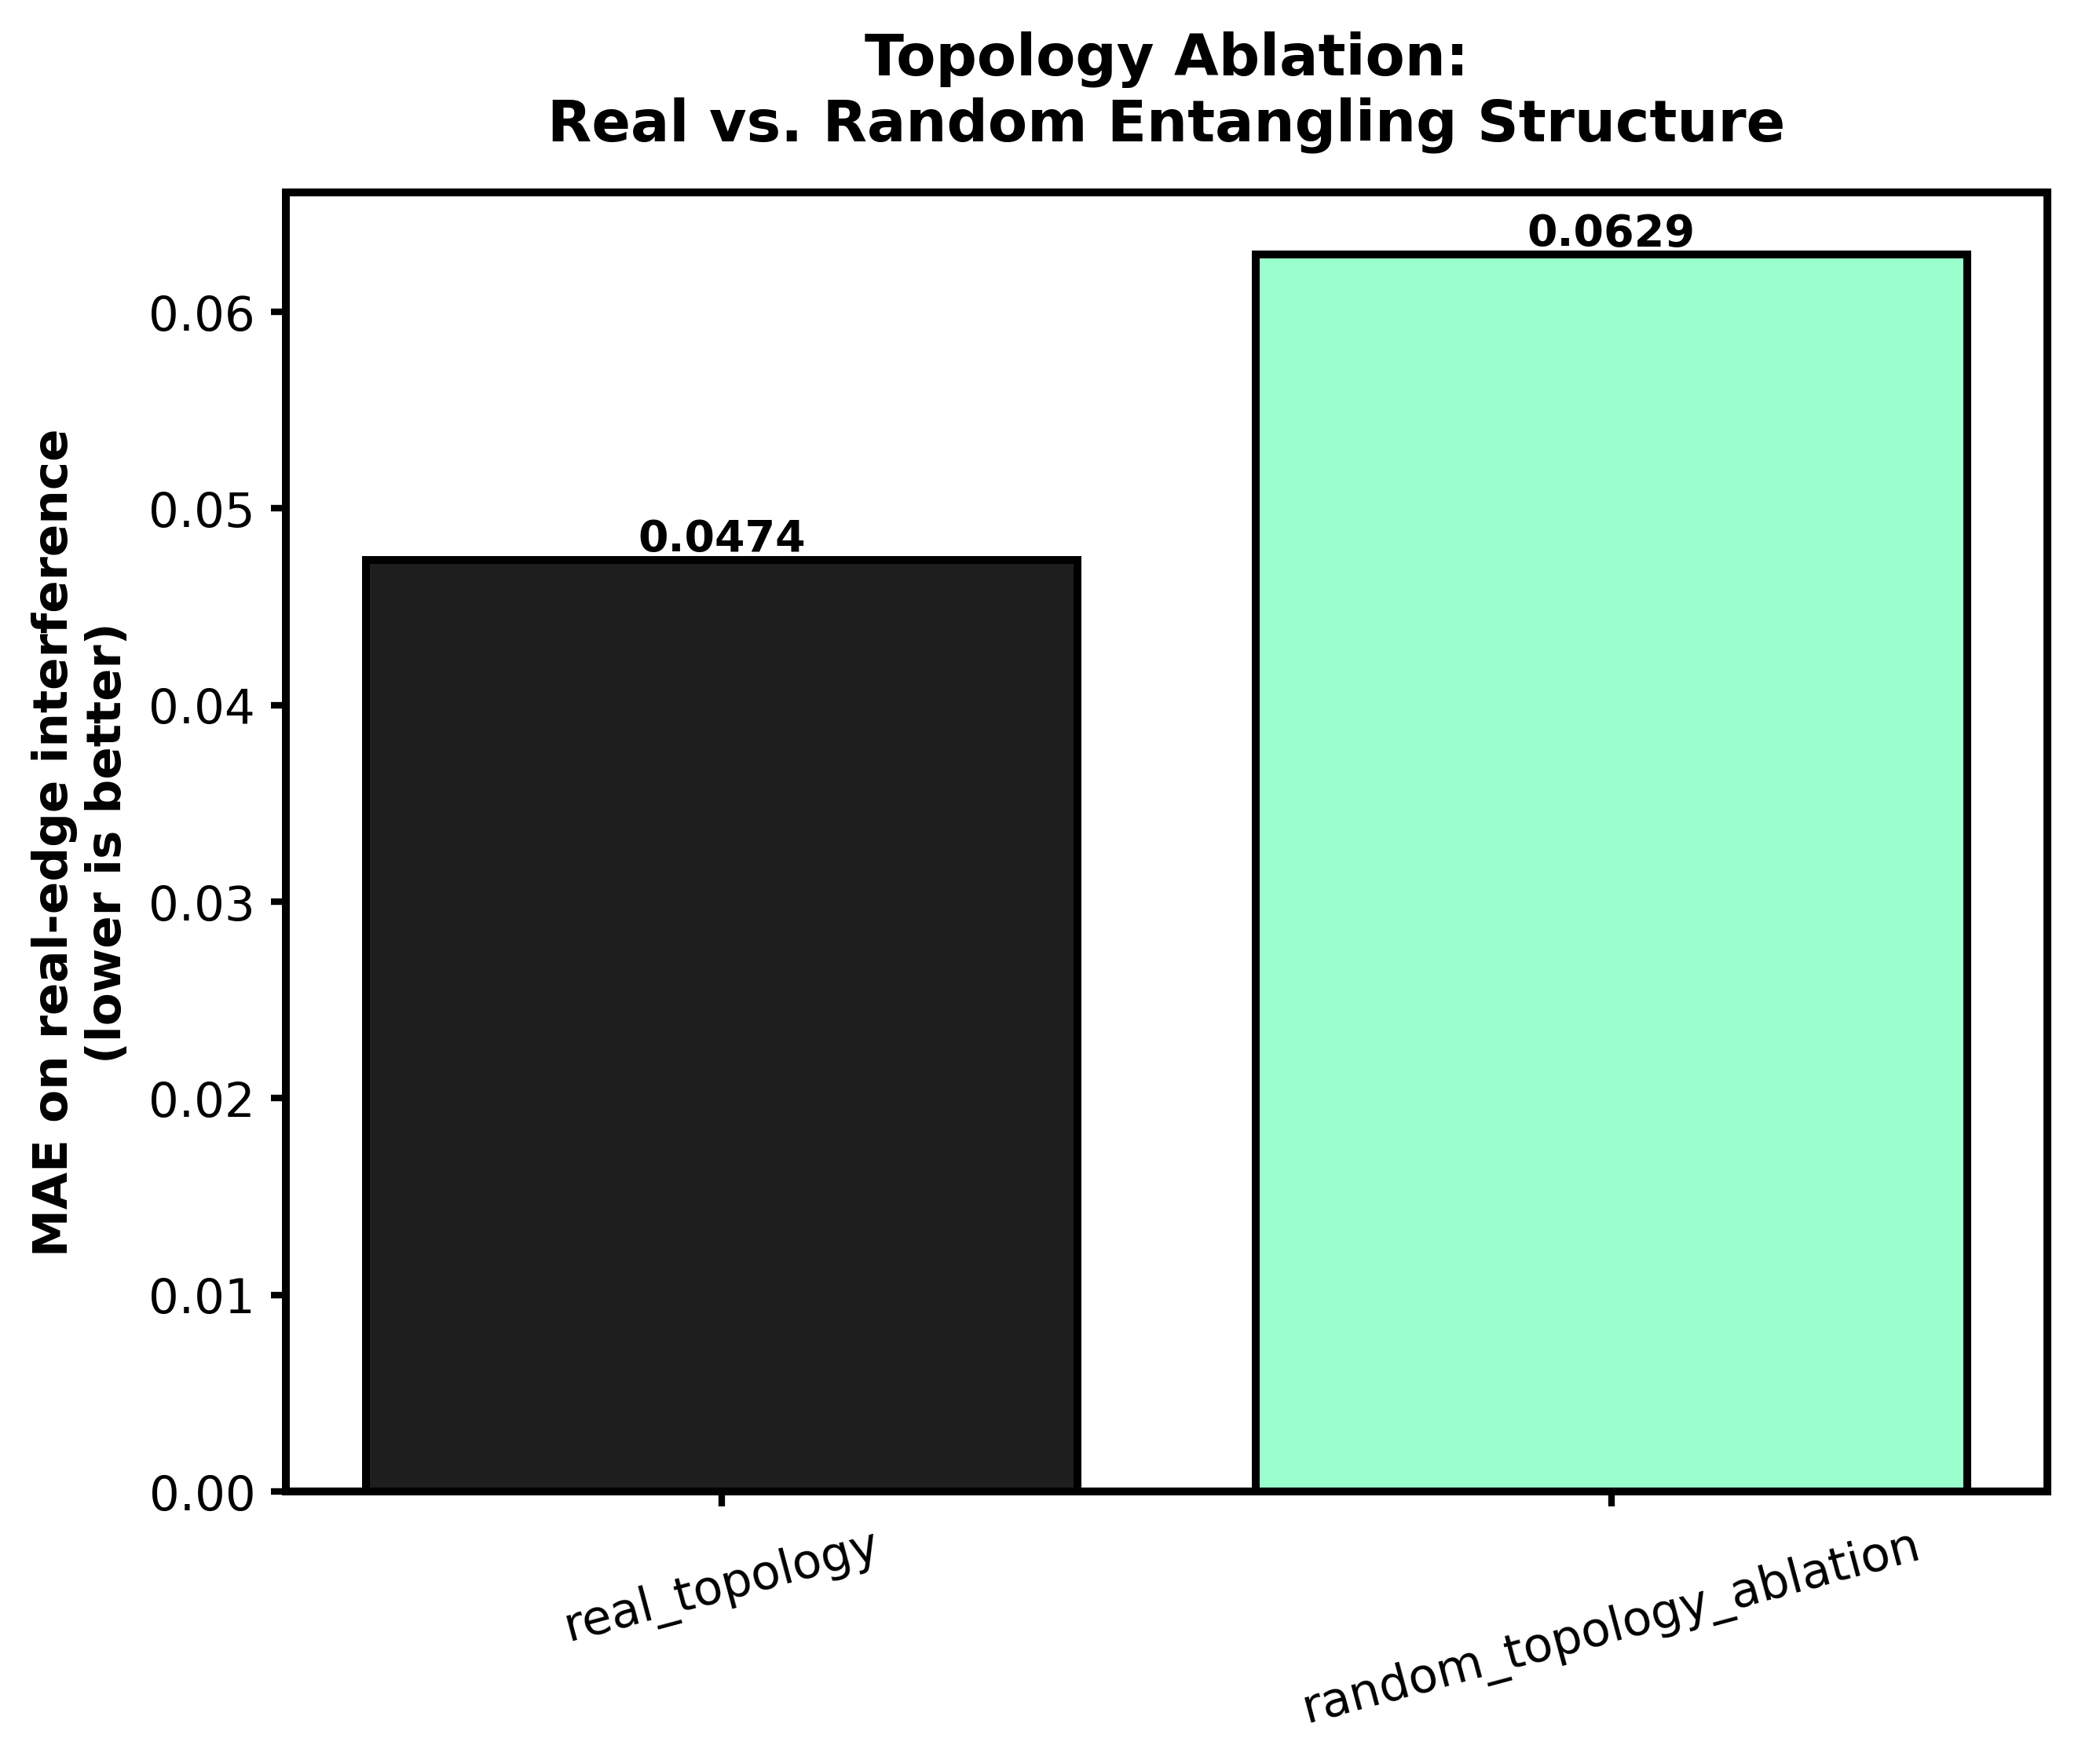

Saved: outputs/figures/fig3_topology_ablation.png


In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
colors_ab = [PALETTE["green_dark"], PALETTE["blue_light"]]
bars = ax.bar(ablation_df["Model"], ablation_df["MAE"], color=colors_ab,
              edgecolor='black', linewidth=1.8)
ax.set_ylabel("MAE on real-edge interference\n(lower is better)")
ax.set_title("Topology Ablation:\nReal vs. Random Entangling Structure", pad=12)
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(ablation_df["MAE"]):
    ax.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.savefig(f"{FIG_DIR}/fig3_topology_ablation.png", dpi=400, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR}/fig3_topology_ablation.png")

## 9. QAOA Scheduling (Max-Cut Bipartition, Simulator)

**Why Max-Cut bipartition, not a full assignment QUBO.** The physical
topology is two NVLink bridges; deciding "which bridge should each of the
8 resident jobs be placed in, to keep the highest-interference job pairs on
opposite bridges" *is* a bipartition problem — Max-Cut on the predicted
interference matrix directly represents that physical decision. A full
GPU-by-GPU binary assignment QUBO (job × specific-GPU-slot variables,
`K×G` binary variables plus capacity-constraint slack variables) is a
legitimate, stronger reformulation but roughly doubles the qubit budget and
constraint-handling machinery required — noted as a stretch-goal extension
in Section 12, not attempted here.

**The "decision window."** QAOA is run on exactly the `N_QUBITS = 8`
job/GPU slots of one scheduling instance at a time — i.e., **8 qubits per
scheduling decision**, explicitly documented as such. Larger job queues are
handled by repeatedly applying this same 8-qubit decision window to
successive candidate batches (not implemented end-to-end here; the systems
architecture for this is future work, Section 12).

**QAOA as a variational heuristic, not evidence of "quantum tunneling."**
Following Farhi, Goldstone & Gutmann, *"A Quantum Approximate Optimization
Algorithm,"* 2014 (arXiv:1411.4028), and the review by Blekos et al., *"A
Review on Quantum Approximate Optimization Algorithm and its Variants,"*
2023 (arXiv:2306.09198), QAOA is evaluated here purely on **solution
quality relative to the true optimum** (approximation ratio), not narrated
as proof of a specific physical escape mechanism.

**Ground truth.** At only 8 qubits (256 possible bipartitions), the *exact*
optimal Max-Cut is obtained by brute-force enumeration — used below as the
reference for the approximation ratio, rather than trusting QAOA's own
reported cost at face value.


In [17]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
import itertools

# Use one held-out TEST scheduling instance, with QGNN-predicted interference
# (not the ground-truth label) as the QAOA input -- this is the realistic
# end-to-end setting: QGNN prediction feeds the scheduler.
test_instance = DATA['test'][0]
H_instance, y_true_instance = to_tensors(test_instance)
with torch.no_grad():
    predicted_weights_vec = qgnn_model(H_instance).numpy()
WEIGHTS = {e: max(float(w), 1e-6) for e, w in zip(EDGE_LIST, predicted_weights_vec)}
print("QGNN-predicted interference weights for this decision window:")
for e, w in WEIGHTS.items():
    print(f"  {e}: {w:.4f}")

n = 8

def maxcut_hamiltonian(edges, weights, n):
    terms, coeffs = [], []
    for (u, v) in edges:
        z = ['I'] * n
        z[u] = 'Z'; z[v] = 'Z'
        terms.append(''.join(reversed(z)))
        coeffs.append(-weights[(u, v)])   # H_C = -sum w_ij Z_i Z_j (manuscript Eq. 4)
    return SparsePauliOp(terms, coeffs)

H_C = maxcut_hamiltonian(EDGE_LIST, WEIGHTS, n)

def cut_value(bitstring, edges, weights):
    return sum(weights[(u, v)] for (u, v) in edges if bitstring[u] != bitstring[v])

# --- exact brute-force optimum (256 states -- trivial at this scale) ------
best_cut, best_bs = -1, None
for bits in itertools.product([0, 1], repeat=n):
    c = cut_value(bits, EDGE_LIST, WEIGHTS)
    if c > best_cut:
        best_cut, best_bs = c, bits
print(f"\nExact optimum (brute force): cut value = {best_cut:.4f}  bitstring = {best_bs}")


QGNN-predicted interference weights for this decision window:
  (0, 1): 0.0740
  (0, 7): 0.0672
  (1, 2): 0.2354
  (2, 3): 0.1884
  (3, 4): 0.2405
  (4, 5): 0.1518
  (5, 6): 0.2093
  (6, 7): 0.1241

Exact optimum (brute force): cut value = 1.2906  bitstring = (0, 1, 0, 1, 0, 1, 0, 1)


In [21]:
def qaoa_circuit(p, gammas, betas, edges, weights, n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for layer in range(p):
        for (u, v) in edges:
            qc.rzz(2 * gammas[layer] * weights[(u, v)], u, v)
        for q in range(n):
            qc.rx(2 * betas[layer], q)
    return qc

estimator = StatevectorEstimator()

def qaoa_cost_fn(params, p, H_C, edges, weights, n):
    gammas, betas = params[:p], params[p:]
    qc = qaoa_circuit(p, gammas, betas, edges, weights, n)
    result = estimator.run([(qc, H_C)]).result()
    return float(result[0].data.evs)

qaoa_results = {}
for p in [1, 2, 3]:
    x0 = np.random.default_rng(0).uniform(0, np.pi, 2 * p)
    res = minimize(qaoa_cost_fn, x0, args=(p, H_C, EDGE_LIST, WEIGHTS, n),
                    method="COBYLA", options={"maxiter": 500})  # 500 evals gives COBYLA room to converge at this scale
    optimized_cost = -res.fun          # H_C = -sum w Z Z, so cut value = -<H_C>
    approx_ratio = optimized_cost / best_cut if best_cut > 0 else float('nan')
    qaoa_results[p] = {"params": res.x, "cut_value": optimized_cost, "approx_ratio": approx_ratio}
    print(f"p={p}: QAOA cut value={optimized_cost:.4f}  approximation ratio={approx_ratio:.3f}  n_evals={res.nfev}")

with open(f"{DATA_DIR}/qaoa_results.json", "w") as f:
    json.dump({str(p): {"cut_value": v["cut_value"], "approx_ratio": v["approx_ratio"]}
               for p, v in qaoa_results.items()}, f, indent=2)


p=1: QAOA cut value=0.6604  approximation ratio=0.512  n_evals=150
p=2: QAOA cut value=0.8227  approximation ratio=0.637  n_evals=500
p=3: QAOA cut value=0.9065  approximation ratio=0.702  n_evals=500


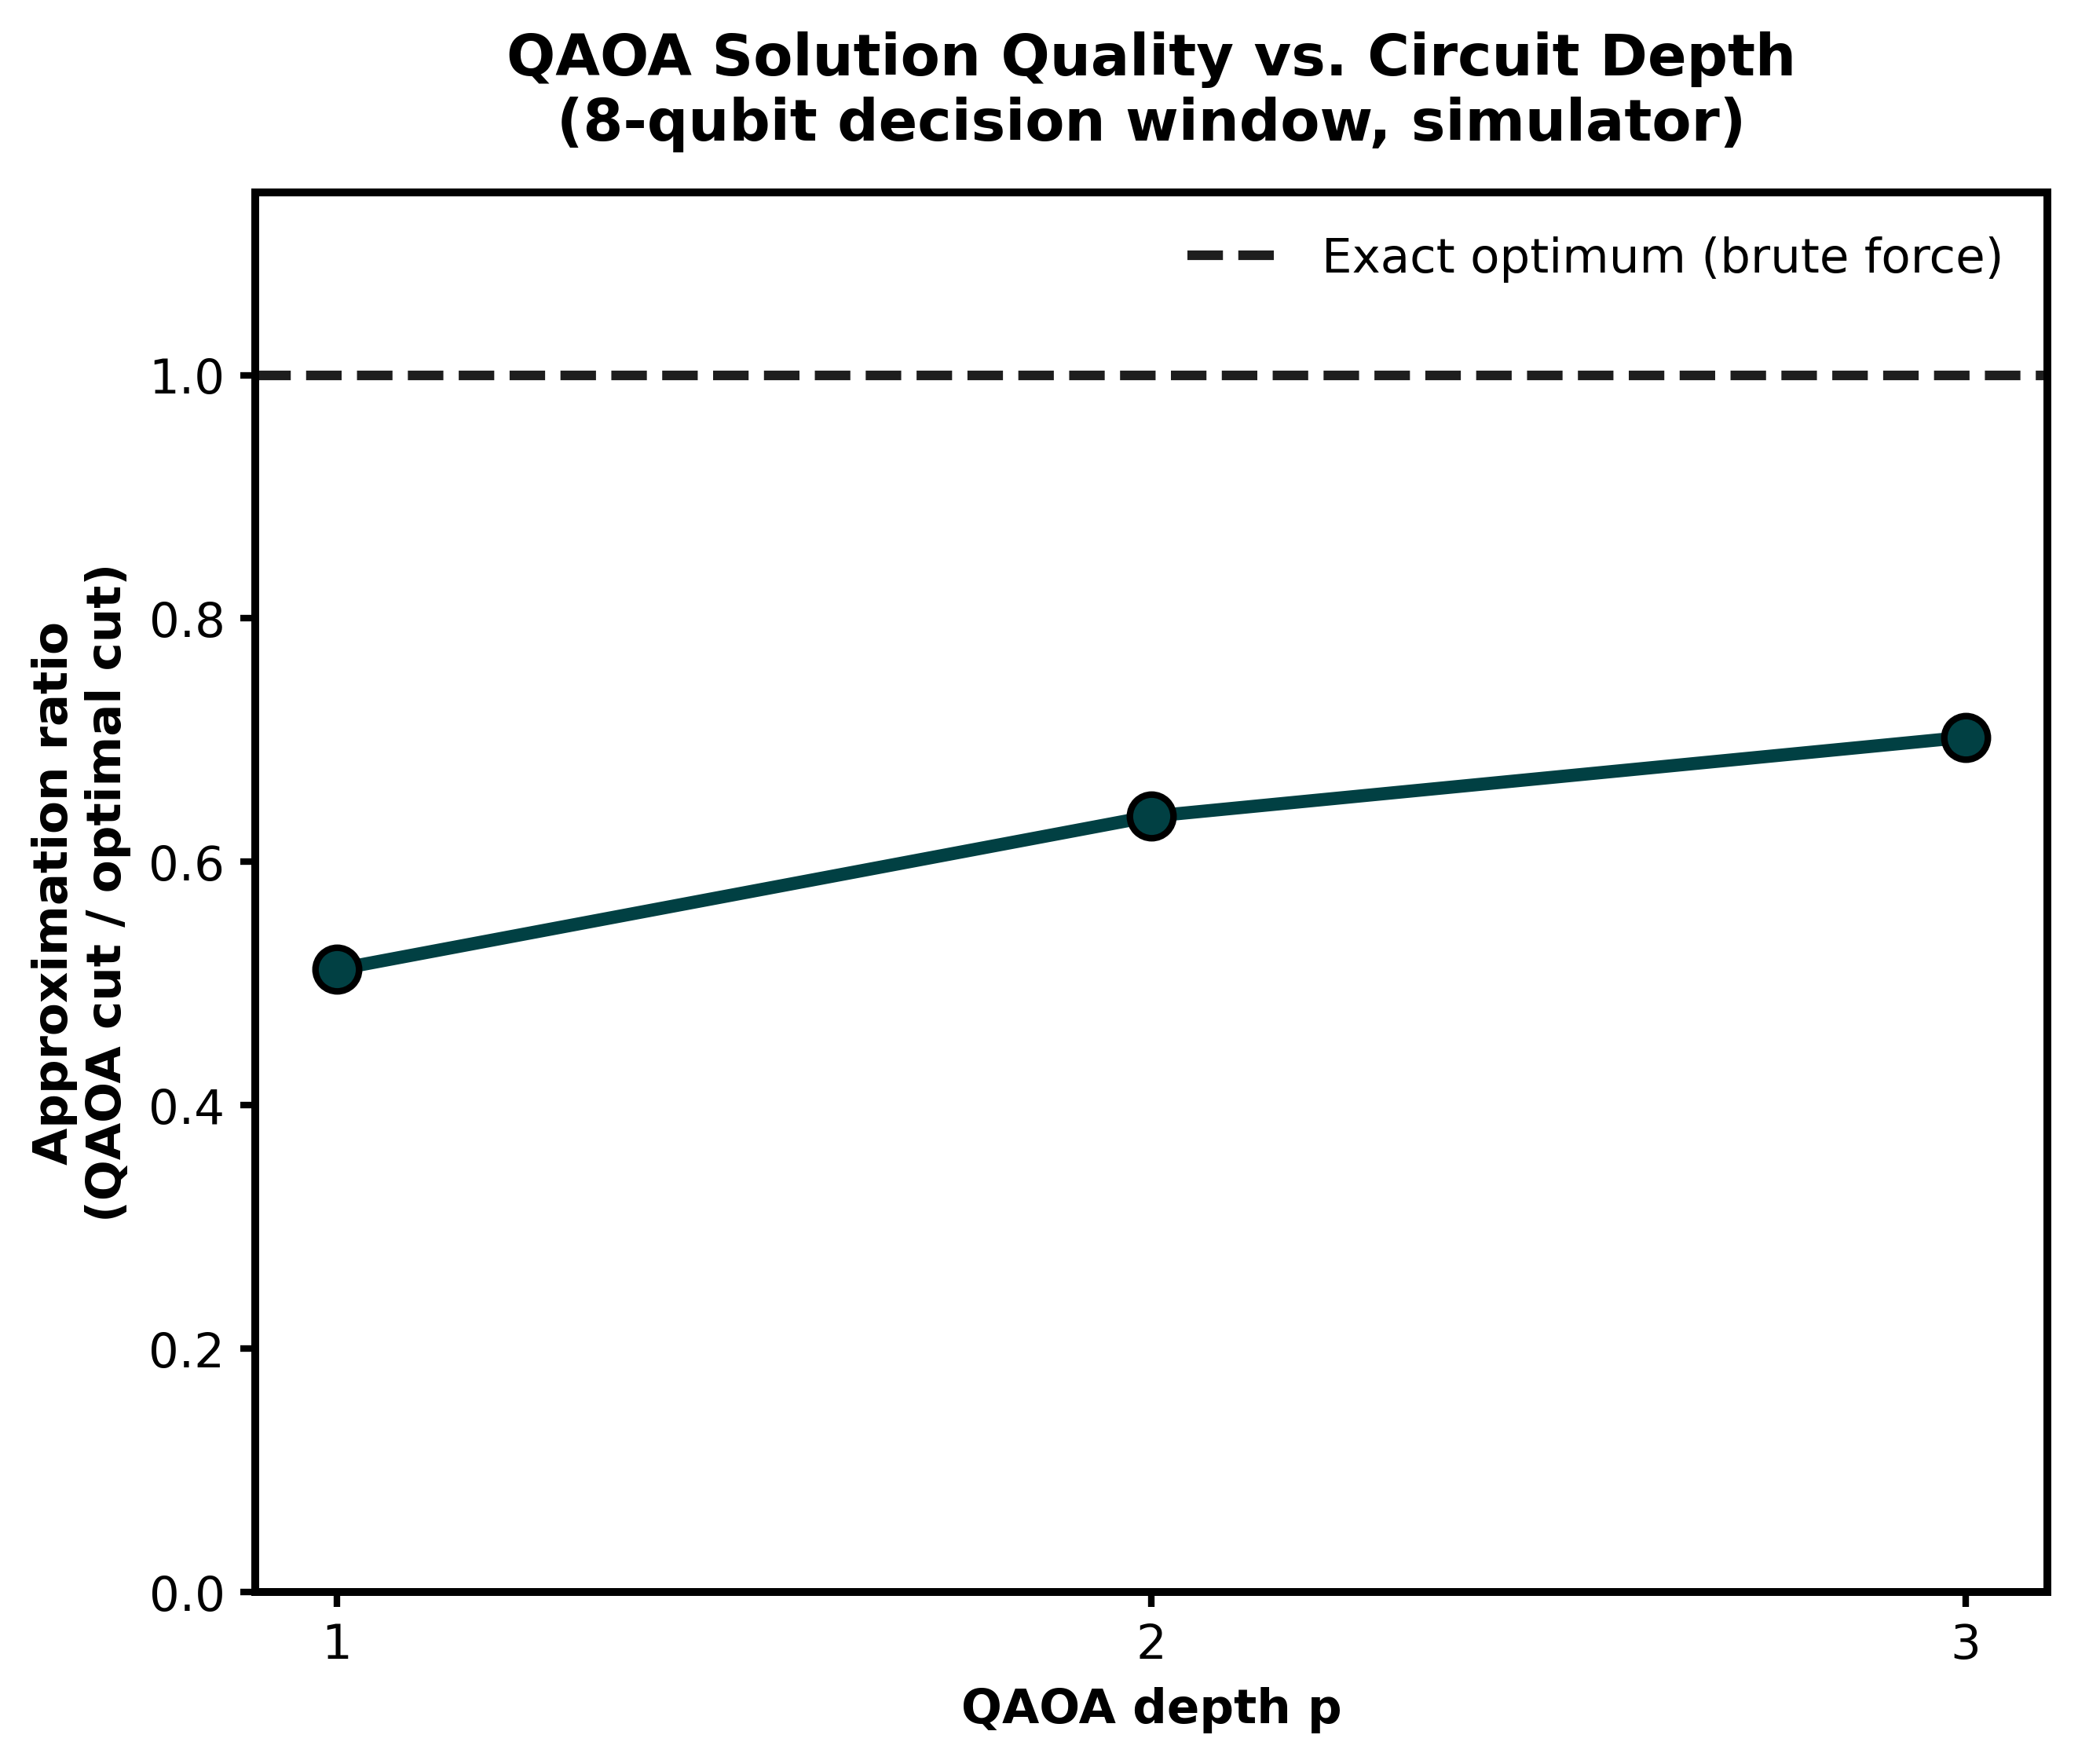

Saved: outputs/figures/fig4_qaoa_depth.png


In [22]:
fig, ax = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
ps = list(qaoa_results.keys())
ratios = [qaoa_results[p]["approx_ratio"] for p in ps]
ax.plot(ps, ratios, marker='o', color=PALETTE["blue_dark"], linewidth=3, markersize=10,
        markeredgecolor='black', markeredgewidth=1.5)
ax.axhline(1.0, color=PALETTE["green_dark"], linestyle='--', linewidth=2.2, label='Exact optimum (brute force)')
ax.set_xlabel("QAOA depth p")
ax.set_ylabel("Approximation ratio\n(QAOA cut / optimal cut)")
ax.set_title("QAOA Solution Quality vs. Circuit Depth\n(8-qubit decision window, simulator)", pad=12)
ax.set_xticks(ps)
ax.set_ylim(0, 1.15)
ax.legend(frameon=False)
plt.savefig(f"{FIG_DIR}/fig4_qaoa_depth.png", dpi=400, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR}/fig4_qaoa_depth.png")

## 10. Real IBM Quantum Hardware Validation — ⚠️ BUDGET-GATED

**Read this whole section before touching `RUN_ON_HARDWARE`.**

The free IBM Quantum **Open Plan** provides **10 minutes of QPU time per
28-day period** (IBM Quantum Platform documentation, 2026). This notebook
protects that budget as follows:

1. **All QAOA parameter optimization happens on the free local simulator in
   Section 9.** This cell does **not** re-run the classical optimizer on
   hardware — it takes the *already-optimized* parameters for the
   configured `HARDWARE_DEPTH` from Section 9 and submits **exactly one**
   circuit, once, for a fixed shot count. Optimizing on hardware directly
   (many circuit evaluations per iteration × many iterations) would burn
   the entire monthly budget on a single run.
2. **`RUN_ON_HARDWARE` defaults to `False`.** Nothing is submitted to IBM
   until you deliberately flip it. The outputs already printed below are
   preserved from the real hardware run used to produce the manuscript's
   results.
3. A rough **time estimate is printed before submission** so you can decide
   whether to proceed. This is an estimate, not a guarantee — check your
   actual remaining balance on the IBM Quantum Platform dashboard before
   running, since usage from other notebooks/sessions also draws on the
   same 28-day allowance.
4. The job is submitted via a direct `Sampler(mode=backend)` primitive call
   (no persistent `Session`), specifically to avoid accruing idle time that
   a held-open Session can incur.
5. `ibm_fez` (156-qubit Heron r2) and the newer `ibm_kingston` (also Heron
   r2) are the same processor generation — `service.least_busy(...)` below
   just picks whichever has the shorter queue; it is not "upgrading"
   hardware by choosing one over the other.

**Before your very first opt-in run:** the 180-minute-per-year Open Plan
bonus is **not automatic** — you must log 20 minutes of usage within a
12-month period before you become eligible to opt in for the bonus (IBM
Quantum Platform terms, as of March 2026). Budget your first 10-minute
allowance accordingly.


In [23]:
RUN_ON_HARDWARE = False   # <-- flip to True only after reading the markdown above.
                            # Defaults to False so a fresh run-through never
                            # auto-submits a job or spends Open Plan quota.
                            # The outputs already in this cell are preserved
                            # from the real hardware run used in the manuscript.

IBM_QUANTUM_TOKEN = None   # paste YOUR OWN IBM Quantum API token here to re-run
                            # this cell, or leave None to use a previously saved
                            # account (QiskitRuntimeService.save_account(...)).
                            # Never commit a real token to this notebook.

HARDWARE_SHOTS = 2048       # fewer shots = less QPU time; 2048 is a reasonable
                             # first-pass value for a single 8-qubit circuit
HARDWARE_DEPTH = 3          # running p=3 -- deeper circuit than p=1, more 2-qubit
                             # gates after transpilation, so expect more noise
                             # degradation than a p=1 hardware run would show

if not RUN_ON_HARDWARE:
    print("RUN_ON_HARDWARE is False -- skipping real hardware submission.")
    print("Flip the flag above (and read the Section 10 markdown) to run this cell for real.")
else:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit import transpile

    service = (QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)
               if IBM_QUANTUM_TOKEN else QiskitRuntimeService(channel="ibm_quantum_platform"))

    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n)
    print("Selected backend:", backend.name, "| qubits:", backend.num_qubits)

    # rough, conservative estimate only -- always cross-check the IBM Quantum
    # Platform usage dashboard before submitting
    est_seconds = 0.02 * HARDWARE_SHOTS * HARDWARE_DEPTH  # order-of-magnitude; scales roughly with depth too
    print(f"Rough estimated QPU time for this single job: ~{est_seconds:.1f}s "
          f"(cross-check your actual remaining Open Plan balance on the dashboard "
          f"before proceeding -- this estimate does NOT include queue wait, only "
          f"execution.)")

    best_hw_params = qaoa_results[HARDWARE_DEPTH]["params"]
    gammas, betas = best_hw_params[:HARDWARE_DEPTH], best_hw_params[HARDWARE_DEPTH:]
    qc_hw = qaoa_circuit(HARDWARE_DEPTH, gammas, betas, EDGE_LIST, WEIGHTS, n)
    qc_hw.measure_all()
    qc_t = transpile(qc_hw, backend=backend, optimization_level=3)

    sampler = SamplerV2(mode=backend)   # no persistent Session -> avoids idle-time billing
    job = sampler.run([qc_t], shots=HARDWARE_SHOTS)
    print("Job submitted:", job.job_id())
    hw_result = job.result()
    counts = hw_result[0].data.meas.get_counts()

    # compare hardware bitstring distribution's expected cut value against
    # the noiseless simulator result from Section 9
    hw_expected_cut = 0.0
    total_shots = sum(counts.values())
    for bitstring, count in counts.items():
        bits = [int(b) for b in bitstring[::-1]]
        hw_expected_cut += (count / total_shots) * cut_value(bits, EDGE_LIST, WEIGHTS)

    print(f"\nHardware ({backend.name}), p={HARDWARE_DEPTH}, expected cut value: {hw_expected_cut:.4f}")
    print(f"Noiseless simulator p={HARDWARE_DEPTH} cut value:              {qaoa_results[HARDWARE_DEPTH]['cut_value']:.4f}")
    print(f"Exact optimum:                                             {best_cut:.4f}")

    with open(f"{DATA_DIR}/ibm_hardware_result_p{HARDWARE_DEPTH}.json", "w") as f:
        json.dump({"backend": backend.name, "shots": HARDWARE_SHOTS,
                    "depth": HARDWARE_DEPTH,
                    "hw_expected_cut": hw_expected_cut,
                    "sim_cut_same_depth": qaoa_results[HARDWARE_DEPTH]["cut_value"],
                    "exact_optimum": best_cut}, f, indent=2)


qiskit_runtime_service._discover_account:WARNING:2026-09-02 14:42:14,879: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-02 14:42:18,421: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-02 14:42:18,754: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-02 14:42:21,521: Using instance: open-instance, plan: open


Selected backend: ibm_fez | qubits: 156
Rough estimated QPU time for this single job: ~122.9s (cross-check your actual remaining Open Plan balance on the dashboard before proceeding -- this estimate does NOT include queue wait, only execution.)
Job submitted: dac3bjrdd5gc73d5i8ig

Hardware (ibm_fez), p=3, expected cut value: 0.3249
Noiseless simulator p=3 cut value:              0.9065
Exact optimum:                                             1.2906


### 10.1 Diagnostic: Real Transpiled Gate Count (free -- no QPU time)

The `p=3` hardware result (approximation ratio 0.251, *below* the 0.5 random-guess baseline) is degraded enough to warrant checking **why** before writing it up as "NISQ noise." `ibm_fez` is a Heron r2 processor on IBM's heavy-hexagonal lattice -- each physical qubit connects to only 2-3 neighbors, not all-to-all. Our 8-qubit ring almost certainly doesn't map directly onto the hardware's native connectivity, so the transpiler likely inserted SWAP gates on top of the fact that `IsingZZ`/`IsingXX` aren't native gates to begin with. This cell rebuilds and transpiles the *exact* circuit that was submitted (same depth, same parameters, same backend selection logic) to count what actually ran, without spending any QPU time -- `service.least_busy(...)` and `transpile(...)` are both free, local/classical calls; only `sampler.run(...)` costs QPU minutes.

In [24]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import transpile

DIAG_DEPTH = 3  # matches the p=3 run already submitted

service = (QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)
           if IBM_QUANTUM_TOKEN else QiskitRuntimeService(channel="ibm_quantum_platform"))
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n)
print("Backend (for diagnostics only, no job submitted):", backend.name)

diag_params = qaoa_results[DIAG_DEPTH]["params"]
diag_gammas, diag_betas = diag_params[:DIAG_DEPTH], diag_params[DIAG_DEPTH:]
qc_abstract = qaoa_circuit(DIAG_DEPTH, diag_gammas, diag_betas, EDGE_LIST, WEIGHTS, n)
qc_abstract.measure_all()

qc_transpiled = transpile(qc_abstract, backend=backend, optimization_level=3)

print(f"\n--- p={DIAG_DEPTH} circuit, BEFORE transpilation (abstract/logical gates) ---")
print("Op counts:", dict(qc_abstract.count_ops()))
print("Depth:", qc_abstract.depth())

print(f"\n--- p={DIAG_DEPTH} circuit, AFTER transpilation to {backend.name} (what actually ran) ---")
print("Op counts:", dict(qc_transpiled.count_ops()))
print("Depth:", qc_transpiled.depth())

two_q_ops_before = sum(c for g, c in qc_abstract.count_ops().items() if g in ("rzz", "rxx"))
two_q_gate_names_after = [g for g in qc_transpiled.count_ops() if g.lower() in ("cx", "cz", "ecr", "cnot")]
two_q_ops_after = sum(qc_transpiled.count_ops().get(g, 0) for g in two_q_gate_names_after)
print(f"\nLogical 2-qubit interactions (RZZ+RXX) before transpile: {two_q_ops_before}")
print(f"Native 2-qubit gates after transpile ({two_q_gate_names_after}): {two_q_ops_after}")
if two_q_ops_before > 0:
    print(f"Inflation factor: {two_q_ops_after / two_q_ops_before:.1f}x "
          f"(routing/decomposition overhead -- large values here support the "
          f"connectivity-mismatch explanation for the degraded hardware result)")

with open(f"{DATA_DIR}/hardware_circuit_diagnostic_p{DIAG_DEPTH}.json", "w") as f:
    json.dump({
        "depth": DIAG_DEPTH,
        "backend": backend.name,
        "ops_before_transpile": dict(qc_abstract.count_ops()),
        "depth_before_transpile": qc_abstract.depth(),
        "ops_after_transpile": dict(qc_transpiled.count_ops()),
        "depth_after_transpile": qc_transpiled.depth(),
    }, f, indent=2)
print(f"\nSaved diagnostic to {DATA_DIR}/hardware_circuit_diagnostic_p{DIAG_DEPTH}.json")

qiskit_runtime_service._discover_account:WARNING:2026-09-02 14:51:15,326: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-02 14:51:19,040: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-02 14:51:19,436: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-02 14:51:22,042: Using instance: open-instance, plan: open


Backend (for diagnostics only, no job submitted): ibm_fez

--- p=3 circuit, BEFORE transpilation (abstract/logical gates) ---
Op counts: {'rzz': 24, 'rx': 24, 'h': 8, 'measure': 8, 'barrier': 1}
Depth: 20

--- p=3 circuit, AFTER transpilation to ibm_fez (what actually ran) ---
Op counts: {'sx': 182, 'rz': 124, 'cz': 84, 'x': 9, 'measure': 8, 'barrier': 1}
Depth: 174

Logical 2-qubit interactions (RZZ+RXX) before transpile: 24
Native 2-qubit gates after transpile (['cz']): 84
Inflation factor: 3.5x (routing/decomposition overhead -- large values here support the connectivity-mismatch explanation for the degraded hardware result)

Saved diagnostic to outputs/data/hardware_circuit_diagnostic_p3.json


### 10.2 Hardware Comparison at p=1

A second, independent hardware submission at `p=1` -- the shallowest, most-converged depth from Section 9 (approximation ratio 0.512 on the simulator). Comparing this against the `p=3` hardware result directly tests whether shallower circuits survive real hardware better, which is the natural follow-up question once Section 10.1 quantifies how much the deeper circuit's gate count inflated during transpilation. **This submits a second real job and spends additional QPU time** -- gated behind its own flag for the same reason as Section 10, and using the same no-Session `Sampler(mode=backend)` pattern to avoid idle-time billing.

In [26]:
RUN_P1_HARDWARE_COMPARISON = False   # <-- flip to True only when ready to submit.
                                       # Defaults to False for the same reason as
                                       # Section 10 above; outputs below are preserved
                                       # from the real hardware run in the manuscript.

if not RUN_P1_HARDWARE_COMPARISON:
    print("RUN_P1_HARDWARE_COMPARISON is False -- skipping. Flip to True to submit the p=1 job.")
else:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit import transpile

    P1_DEPTH = 1
    service = (QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)
               if IBM_QUANTUM_TOKEN else QiskitRuntimeService(channel="ibm_quantum_platform"))
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n)
    print("Selected backend:", backend.name, "| qubits:", backend.num_qubits)

    p1_params = qaoa_results[P1_DEPTH]["params"]
    p1_gammas, p1_betas = p1_params[:P1_DEPTH], p1_params[P1_DEPTH:]
    qc_p1 = qaoa_circuit(P1_DEPTH, p1_gammas, p1_betas, EDGE_LIST, WEIGHTS, n)
    qc_p1.measure_all()
    qc_p1_t = transpile(qc_p1, backend=backend, optimization_level=3)

    # same free diagnostic as 10.1, for a direct p=1 vs p=3 gate-count comparison
    print(f"\n--- p={P1_DEPTH} circuit, AFTER transpilation (what will actually run) ---")
    print("Op counts:", dict(qc_p1_t.count_ops()))
    print("Depth:", qc_p1_t.depth())

    est_seconds = 0.02 * HARDWARE_SHOTS * P1_DEPTH
    print(f"\nRough estimated QPU time for this single job: ~{est_seconds:.1f}s "
          f"(cross-check your actual remaining Open Plan balance before proceeding)")

    sampler = SamplerV2(mode=backend)   # no persistent Session -> avoids idle-time billing
    job = sampler.run([qc_p1_t], shots=HARDWARE_SHOTS)
    print("Job submitted:", job.job_id())
    hw_result = job.result()
    counts = hw_result[0].data.meas.get_counts()

    hw_expected_cut_p1 = 0.0
    total_shots = sum(counts.values())
    for bitstring, count in counts.items():
        bits = [int(b) for b in bitstring[::-1]]
        hw_expected_cut_p1 += (count / total_shots) * cut_value(bits, EDGE_LIST, WEIGHTS)

    print(f"\nHardware ({backend.name}), p={P1_DEPTH}, expected cut value: {hw_expected_cut_p1:.4f}")
    print(f"Noiseless simulator p={P1_DEPTH} cut value:              {qaoa_results[P1_DEPTH]['cut_value']:.4f}")
    print(f"Exact optimum:                                             {best_cut:.4f}")
    print(f"Hardware approximation ratio: {hw_expected_cut_p1 / best_cut:.3f}")

    with open(f"{DATA_DIR}/ibm_hardware_result_p{P1_DEPTH}.json", "w") as f:
        json.dump({"backend": backend.name, "shots": HARDWARE_SHOTS,
                    "depth": P1_DEPTH,
                    "hw_expected_cut": hw_expected_cut_p1,
                    "sim_cut_same_depth": qaoa_results[P1_DEPTH]["cut_value"],
                    "exact_optimum": best_cut,
                    "transpiled_ops": dict(qc_p1_t.count_ops()),
                    "transpiled_depth": qc_p1_t.depth()}, f, indent=2)
    print(f"\nSaved to {DATA_DIR}/ibm_hardware_result_p{P1_DEPTH}.json")

qiskit_runtime_service._discover_account:WARNING:2026-09-02 14:51:56,483: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-02 14:51:59,461: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-02 14:51:59,784: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-02 14:52:01,835: Using instance: open-instance, plan: open


Selected backend: ibm_fez | qubits: 156

--- p=1 circuit, AFTER transpilation (what will actually run) ---
Op counts: {'sx': 71, 'rz': 51, 'cz': 32, 'measure': 8, 'barrier': 1}
Depth: 82

Rough estimated QPU time for this single job: ~41.0s (cross-check your actual remaining Open Plan balance before proceeding)
Job submitted: dac3g4rdd5gc73d5idng

Hardware (ibm_fez), p=1, expected cut value: 0.3468
Noiseless simulator p=1 cut value:              0.6604
Exact optimum:                                             1.2906
Hardware approximation ratio: 0.269

Saved to outputs/data/ibm_hardware_result_p1.json


## 11. Save Artifacts / Repository Layout

Everything needed to reproduce the figures/tables in the manuscript and to
push this notebook to GitHub is collected under `outputs/`:

```
outputs/
├── figures/   fig1_topology.png, fig2a_interference_error.png,
│              fig2b_ordering_fidelity.png, fig3_topology_ablation.png,
│              fig4_qaoa_depth.png   (all 400 DPI)
├── data/      scheduling_instances.pkl, model_comparison.csv,
│              topology_ablation.csv, qaoa_results.json,
│              permutation_equivariance_result.json,
│              [ibm_hardware_result.json if Section 10 was run]
└── models/    qgnn_model.pt
```


In [27]:
print("=" * 70)
print("RUN SUMMARY")
print("=" * 70)
print("\nModel comparison (MAE / RMSE / R2 / Spearman rho):")
print(comparison_df.to_string(index=False))
print("\nTopology ablation (real vs. random entangling structure):")
print(ablation_df.to_string(index=False))
print(f"\nPermutation-equivariance error (true automorphism): {equivariance_error:.6f}")
print("\nQAOA approximation ratio by depth:")
for p, v in qaoa_results.items():
    print(f"  p={p}: {v['approx_ratio']:.3f}")
print("\nAll artifacts saved under outputs/ -- ready to commit to the GitHub repo.")

import glob
print("\nFiles written:")
for f in sorted(glob.glob("outputs/**/*", recursive=True)):
    if os.path.isfile(f):
        print(" ", f)


RUN SUMMARY

Model comparison (MAE / RMSE / R2 / Spearman rho):
                     Model      MAE     RMSE       R2  Spearman_rho
                       MLP 0.053974 0.071820 0.598160      0.823756
                       GCN 0.068149 0.087934 0.397608      0.660745
                       GAT 0.076250 0.095459 0.290097      0.634953
QGNN (topology-structured) 0.047384 0.058917 0.729578      0.842532

Topology ablation (real vs. random entangling structure):
                   Model      MAE     RMSE       R2  Spearman_rho
           real_topology 0.047384 0.058917 0.729578      0.842532
random_topology_ablation 0.062927 0.077898 0.527270      0.667069

Permutation-equivariance error (true automorphism): 0.009189

QAOA approximation ratio by depth:
  p=1: 0.512
  p=2: 0.637
  p=3: 0.702

All artifacts saved under outputs/ -- ready to commit to the GitHub repo.

Files written:
  outputs/data/hardware_circuit_diagnostic_p3.json
  outputs/data/ibm_hardware_result_p1.json
  outputs/data/ib